# Assignment 03: DCGAN on MNIST (PyTorch + CUDA)

## Objective
This notebook implements a **Deep Convolutional Generative Adversarial Network (DCGAN)** to generate realistic handwritten digits from the MNIST dataset.

A GAN has two competing neural networks:
- **Generator (G):** takes random noise and tries to produce realistic fake digits.
- **Discriminator (D):** tries to distinguish real MNIST digits from generator outputs.

Through adversarial training, both networks improve over time.

In [11]:
# If torch/torchvision are missing, uncomment and run once.
# %pip install -q torch torchvision matplotlib numpy

import os
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU count:", torch.cuda.device_count())
    print("Active GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
    print("cuDNN benchmark enabled:", torch.backends.cudnn.benchmark)
else:
    device = torch.device("cpu")
    print("No CUDA device found. Notebook will run on CPU, but training will be slower.")

PyTorch version: 2.10.0+cu130
CUDA available: True
GPU count: 1
Active GPU: NVIDIA RTX A4000 Laptop GPU
cuDNN benchmark enabled: True


In [12]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Core settings
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
NOISE_DIM = 100

BATCH_SIZE = 256
EPOCHS = 40
LEARNING_RATE = 2e-4
BETA_1 = 0.5
BETA_2 = 0.999

DATA_DIR = Path("data")
CHECKPOINT_DIR = Path("checkpoints_dcgan_torch")
SAMPLES_DIR = Path("generated_samples_torch")
MODELS_DIR = Path("saved_models_torch")

for d in [DATA_DIR, CHECKPOINT_DIR, SAMPLES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SAVE_EVERY_N_EPOCHS = 5
LOG_INTERVAL_STEPS = 100

print("Configuration:")
print(f"- Device: {device}")
print(f"- Image shape: ({IMG_HEIGHT}, {IMG_WIDTH}, {IMG_CHANNELS})")
print(f"- Noise dimension: {NOISE_DIM}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Epochs: {EPOCHS}")
print(f"- Learning rate: {LEARNING_RATE}, betas: ({BETA_1}, {BETA_2})")

Configuration:
- Device: cuda
- Image shape: (28, 28, 1)
- Noise dimension: 100
- Batch size: 256
- Epochs: 40
- Learning rate: 0.0002, betas: (0.5, 0.999)


## Load MNIST and Perform Quick Data Profiling

Load MNIST via torchvision and validate shapes, dtypes, and class balance before training.

x_train shape: (60000, 28, 28) dtype: torch.uint8
y_train shape: (60000,) dtype: torch.int64

Class distribution in training set:
Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


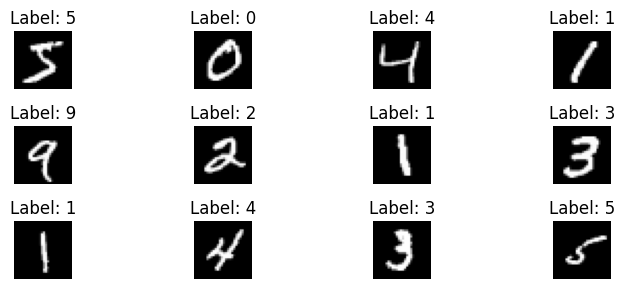

In [13]:
mnist_raw = datasets.MNIST(root=DATA_DIR, train=True, download=True)

x_train_raw = mnist_raw.data
y_train_raw = mnist_raw.targets

print("x_train shape:", tuple(x_train_raw.shape), "dtype:", x_train_raw.dtype)
print("y_train shape:", tuple(y_train_raw.shape), "dtype:", y_train_raw.dtype)

class_counts = torch.bincount(y_train_raw, minlength=10)
print("\nClass distribution in training set:")
for cls, cnt in enumerate(class_counts.tolist()):
    print(f"Digit {cls}: {cnt}")

# Visual sanity check of real images
plt.figure(figsize=(8, 3))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train_raw[i].numpy(), cmap="gray")
    plt.title(f"Label: {int(y_train_raw[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Preprocess Images and Build Efficient DataLoaders

We normalize pixels from `[0, 1]` to `[-1, 1]` because the generator uses `tanh` output.

The DataLoader uses shuffling, pinned memory (for CUDA), and `drop_last=True` for stable batch-dependent training.

In [14]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),  # [0, 1] -> [-1, 1]
    ]
)

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

sample_images, sample_labels = next(iter(train_loader))
print("Batch image shape:", tuple(sample_images.shape))
print("Batch labels shape:", tuple(sample_labels.shape))
print("Approx. steps per epoch:", len(train_loader))

Batch image shape: (256, 1, 28, 28)
Batch labels shape: (256,)
Approx. steps per epoch: 234


## Implement the DCGAN Generator (Lightweight, 28x28 Output)

The generator maps latent noise vectors to synthetic digit images.

In [15]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    def __init__(self, noise_dim=NOISE_DIM):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.model(z)


generator = Generator(NOISE_DIM).to(device)
generator.apply(weights_init)
print(generator)

# Sanity check: output should be (batch, 1, 28, 28)
test_noise = torch.randn(4, NOISE_DIM, 1, 1, device=device)
test_fake = generator(test_noise)
print("Generator output shape:", tuple(test_fake.shape))

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Generator output shape: (4, 1, 28, 28)


## Implement the DCGAN Discriminator (Binary Real/Fake Classifier)

The discriminator receives real or fake images and outputs one logit per image.

In [16]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.model(x).view(-1)


discriminator = Discriminator().to(device)
discriminator.apply(weights_init)
print(discriminator)

real_batch, _ = next(iter(train_loader))
real_batch = real_batch.to(device)
real_logits = discriminator(real_batch[:4])
fake_logits = discriminator(test_fake.detach())

print("Discriminator logits for real batch:", real_logits.detach().cpu().numpy())
print("Discriminator logits for fake batch:", fake_logits.detach().cpu().numpy())

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout2d(p=0.3, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Dropout2d(p=0.3, inplace=False)
    (7): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
  )
)
Discriminator logits for real batch: [-0.5193871   1.4856975  -0.03611623 -0.69486386]
Discriminator logits for fake batch: [ 2.022243   -0.04111346  2.1857204   0.84089446]


## 7Define Adversarial Losses, Optimizers, and Training Hyperparameters

We use `BCEWithLogitsLoss`.

- **Generator loss:** tries to make discriminator classify fake images as real.
- **Discriminator loss:** tries to classify real as real and fake as fake.

Adam settings `lr=2e-4`, `betas=(0.5, 0.999)` are standard stable defaults for DCGAN.

In [17]:
criterion = nn.BCEWithLogitsLoss()


def generator_loss(fake_logits):
    target_real = torch.ones_like(fake_logits, device=fake_logits.device)
    return criterion(fake_logits, target_real)


def discriminator_loss(real_logits, fake_logits):
    target_real = torch.ones_like(real_logits, device=real_logits.device)
    target_fake = torch.zeros_like(fake_logits, device=fake_logits.device)
    real_loss = criterion(real_logits, target_real)
    fake_loss = criterion(fake_logits, target_fake)
    return real_loss + fake_loss


generator_optimizer = optim.Adam(
    generator.parameters(), lr=LEARNING_RATE, betas=(BETA_1, BETA_2)
)
discriminator_optimizer = optim.Adam(
    discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA_1, BETA_2)
)

print("Losses and optimizers configured.")

Losses and optimizers configured.


## Write Training Step Logic

Each iteration performs one adversarial update:
1. Sample random latent vectors.
2. Generate fake images.
3. Compute discriminator and generator losses.
4. Apply gradients to both networks.

In [18]:
# Fixed seed helps visualize progression consistently across epochs.
NUM_EXAMPLES_TO_GENERATE = 16
fixed_noise = torch.randn(NUM_EXAMPLES_TO_GENERATE, NOISE_DIM, 1, 1, device=device)


def train_step(real_images):
    batch_size = real_images.size(0)
    real_images = real_images.to(device, non_blocking=True)

    # --- Train Discriminator ---
    discriminator_optimizer.zero_grad(set_to_none=True)

    real_logits = discriminator(real_images)
    z = torch.randn(batch_size, NOISE_DIM, 1, 1, device=device)
    fake_images = generator(z)
    fake_logits = discriminator(fake_images.detach())

    d_loss = discriminator_loss(real_logits, fake_logits)
    d_loss.backward()
    discriminator_optimizer.step()

    # --- Train Generator ---
    generator_optimizer.zero_grad(set_to_none=True)

    fake_logits_for_g = discriminator(fake_images)
    g_loss = generator_loss(fake_logits_for_g)
    g_loss.backward()
    generator_optimizer.step()

    return g_loss.item(), d_loss.item()

## 9)Build Epoch Training Loop with Progress Logging and Checkpointing

This loop iterates over epochs/batches, logs mean losses, measures epoch time, and saves checkpoints periodically for recovery and grading traceability.

In [19]:
def save_image_grid(images, epoch, out_dir=SAMPLES_DIR, nrows=4, ncols=4):
    images = images.detach().cpu()
    images = (images + 1.0) / 2.0  # denormalize to [0, 1]
    images = torch.clamp(images, 0.0, 1.0)

    fig = plt.figure(figsize=(ncols * 2, nrows * 2))
    for i in range(nrows * ncols):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(images[i, 0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()

    out_path = out_dir / f"epoch_{epoch:03d}.png"
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_checkpoint(epoch):
    checkpoint_path = CHECKPOINT_DIR / f"dcgan_epoch_{epoch:03d}.pt"
    payload = {
        "epoch": epoch,
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "generator_optimizer_state_dict": generator_optimizer.state_dict(),
        "discriminator_optimizer_state_dict": discriminator_optimizer.state_dict(),
        "seed": SEED,
    }
    torch.save(payload, checkpoint_path)
    print("Checkpoint saved:", checkpoint_path.resolve())


def train(dataloader, epochs):
    g_history = []
    d_history = []

    for epoch in range(1, epochs + 1):
        start = time.time()
        g_losses = []
        d_losses = []

        for step, (real_images, _) in enumerate(dataloader, start=1):
            g_loss, d_loss = train_step(real_images)
            g_losses.append(g_loss)
            d_losses.append(d_loss)

            if step % LOG_INTERVAL_STEPS == 0:
                print(
                    f"Epoch {epoch:03d} | Step {step:04d} "
                    f"| G Loss: {g_loss:.4f} | D Loss: {d_loss:.4f}"
                )

        epoch_g = float(np.mean(g_losses))
        epoch_d = float(np.mean(d_losses))
        g_history.append(epoch_g)
        d_history.append(epoch_d)

        print(
            f"Epoch {epoch:03d}/{epochs:03d} completed in {time.time() - start:.1f}s "
            f"| Mean G Loss: {epoch_g:.4f} | Mean D Loss: {epoch_d:.4f}"
        )

        generator.eval()
        with torch.no_grad():
            preview = generator(fixed_noise)
        generator.train()

        save_image_grid(preview, epoch, out_dir=SAMPLES_DIR, nrows=4, ncols=4)

        if epoch % SAVE_EVERY_N_EPOCHS == 0:
            save_checkpoint(epoch)

    return g_history, d_history

## Track Training Curves and Save Sample Grids per Epoch

Run training and then visualize loss curves to inspect adversarial balance.

Epoch 001 | Step 0100 | G Loss: 1.3675 | D Loss: 1.2500
Epoch 001 | Step 0200 | G Loss: 1.0891 | D Loss: 1.2965
Epoch 001/040 completed in 9.1s | Mean G Loss: 1.2647 | Mean D Loss: 1.2749


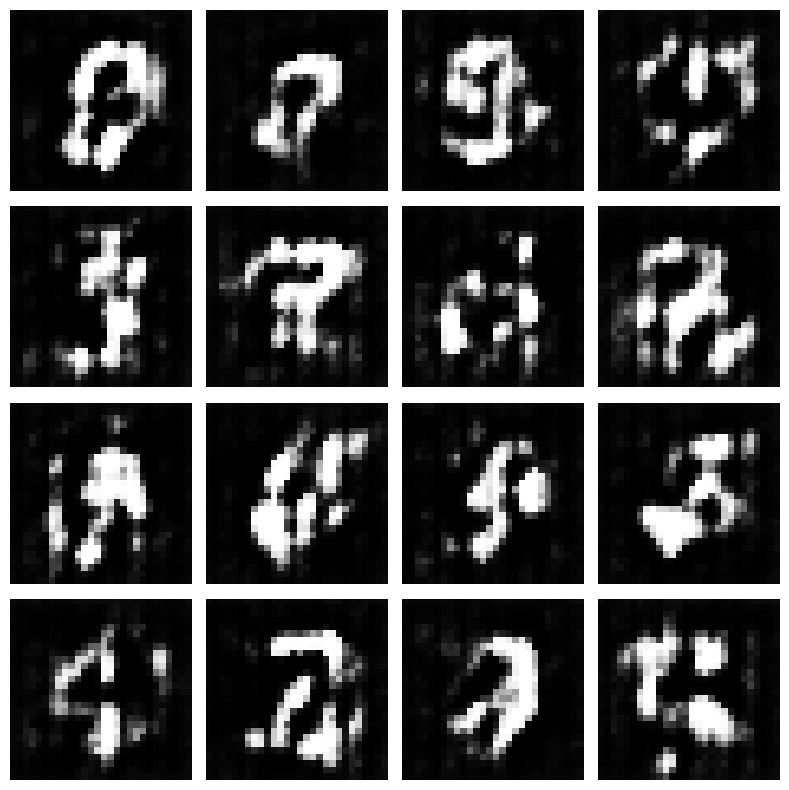

Epoch 002 | Step 0100 | G Loss: 1.1146 | D Loss: 1.2134
Epoch 002 | Step 0200 | G Loss: 1.1559 | D Loss: 1.1292
Epoch 002/040 completed in 9.9s | Mean G Loss: 1.0147 | Mean D Loss: 1.2393


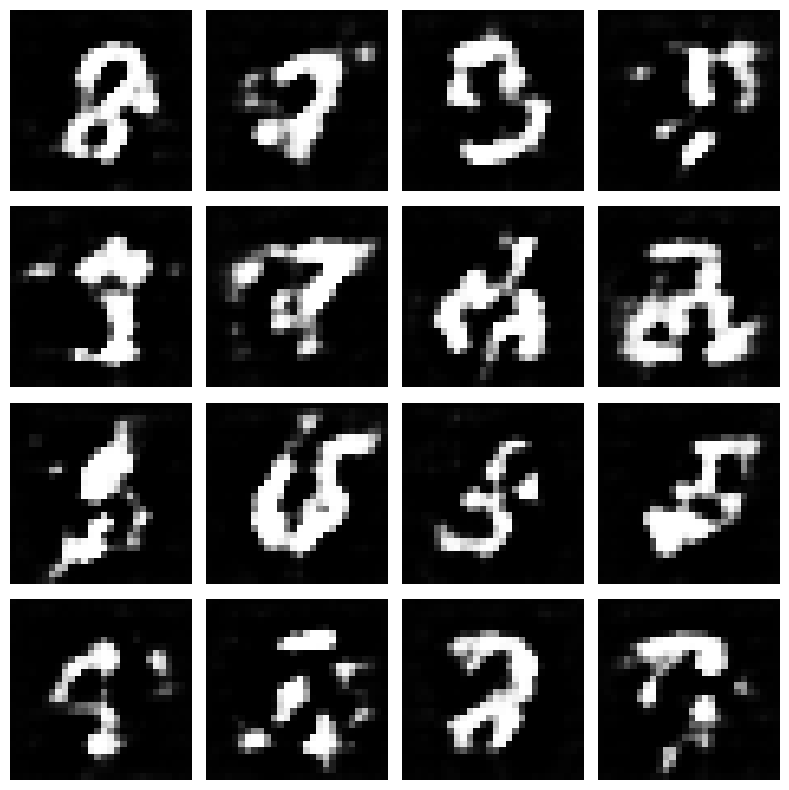

Epoch 003 | Step 0100 | G Loss: 1.2155 | D Loss: 1.0465
Epoch 003 | Step 0200 | G Loss: 1.0423 | D Loss: 1.0642
Epoch 003/040 completed in 10.7s | Mean G Loss: 1.2248 | Mean D Loss: 1.0554


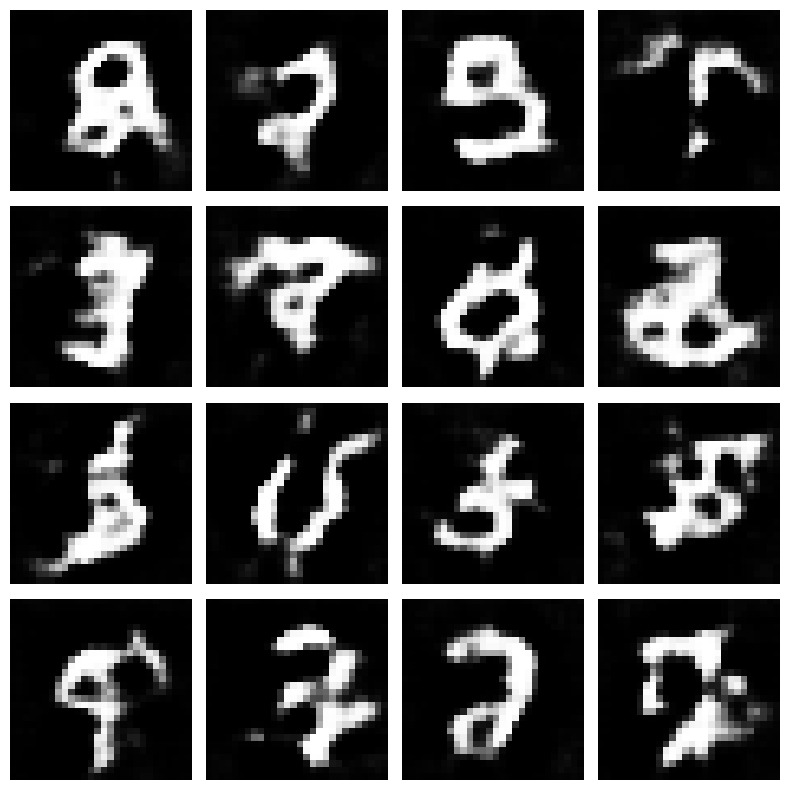

Epoch 004 | Step 0100 | G Loss: 0.8136 | D Loss: 1.1829
Epoch 004 | Step 0200 | G Loss: 0.8437 | D Loss: 1.2488
Epoch 004/040 completed in 10.8s | Mean G Loss: 1.0680 | Mean D Loss: 1.2000


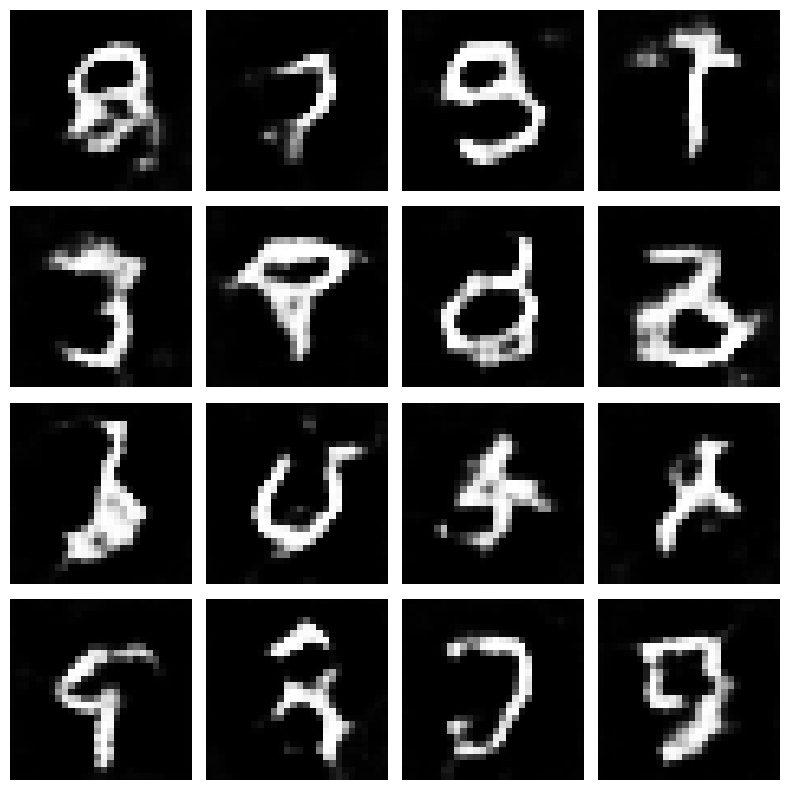

Epoch 005 | Step 0100 | G Loss: 0.9360 | D Loss: 1.3138
Epoch 005 | Step 0200 | G Loss: 1.2162 | D Loss: 1.4212
Epoch 005/040 completed in 10.9s | Mean G Loss: 0.9427 | Mean D Loss: 1.2869


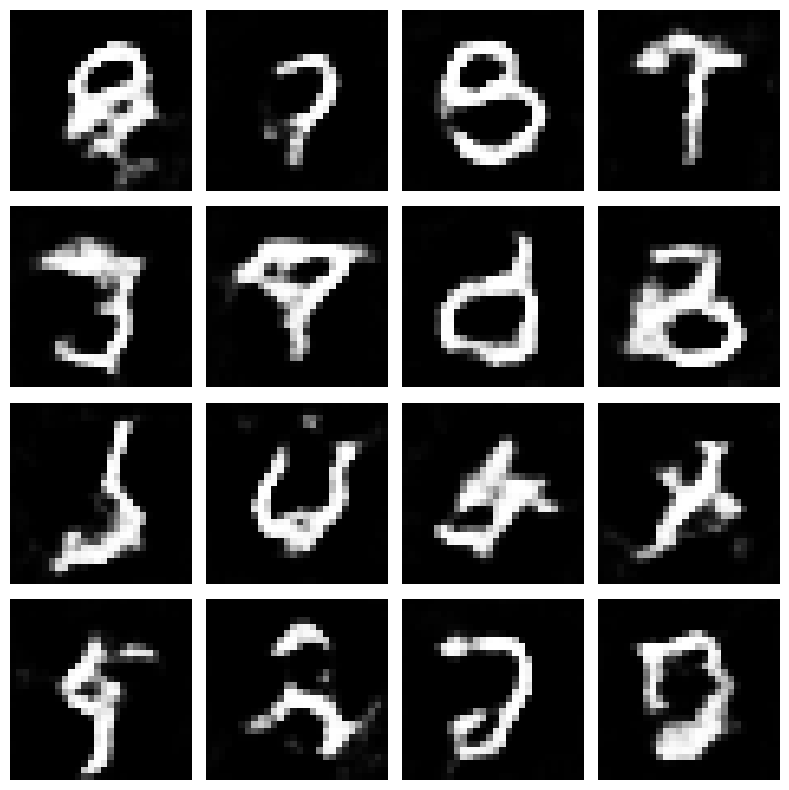

Checkpoint saved: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\checkpoints_dcgan_torch\dcgan_epoch_005.pt
Epoch 006 | Step 0100 | G Loss: 0.8740 | D Loss: 1.2716
Epoch 006 | Step 0200 | G Loss: 1.0198 | D Loss: 1.2279
Epoch 006/040 completed in 10.9s | Mean G Loss: 0.9196 | Mean D Loss: 1.3172


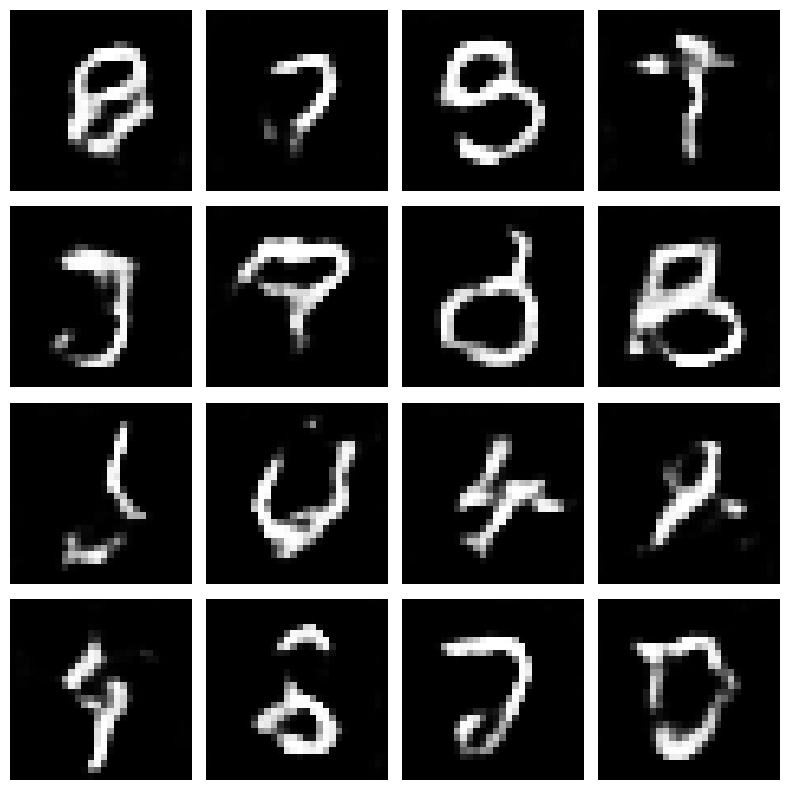

Epoch 007 | Step 0100 | G Loss: 1.0942 | D Loss: 1.3444
Epoch 007 | Step 0200 | G Loss: 0.8925 | D Loss: 1.2829
Epoch 007/040 completed in 11.0s | Mean G Loss: 0.8925 | Mean D Loss: 1.3209


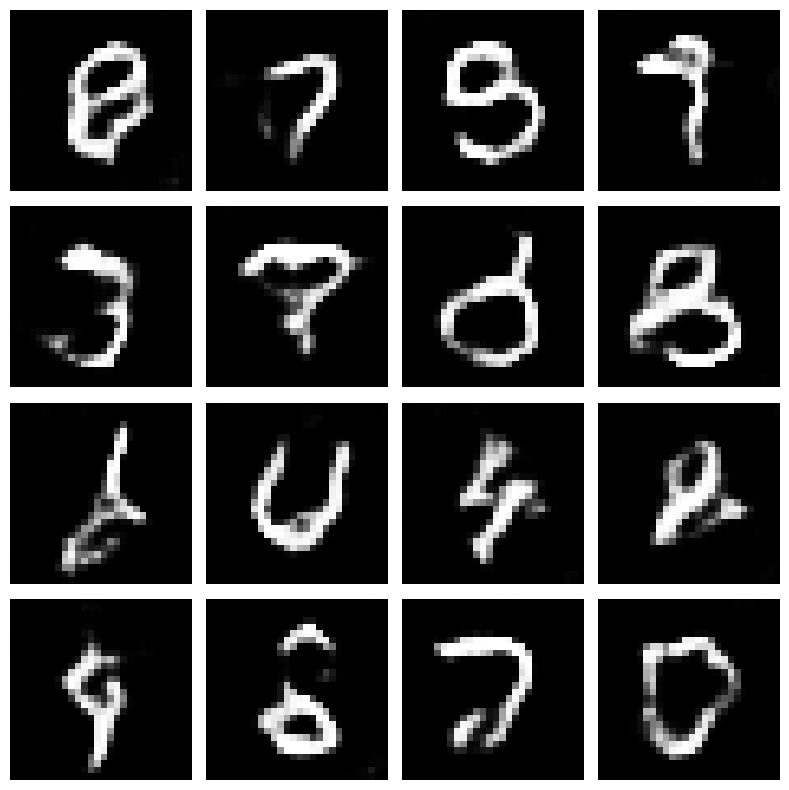

Epoch 008 | Step 0100 | G Loss: 0.8085 | D Loss: 1.3986
Epoch 008 | Step 0200 | G Loss: 0.6833 | D Loss: 1.4032
Epoch 008/040 completed in 11.0s | Mean G Loss: 0.8780 | Mean D Loss: 1.3210


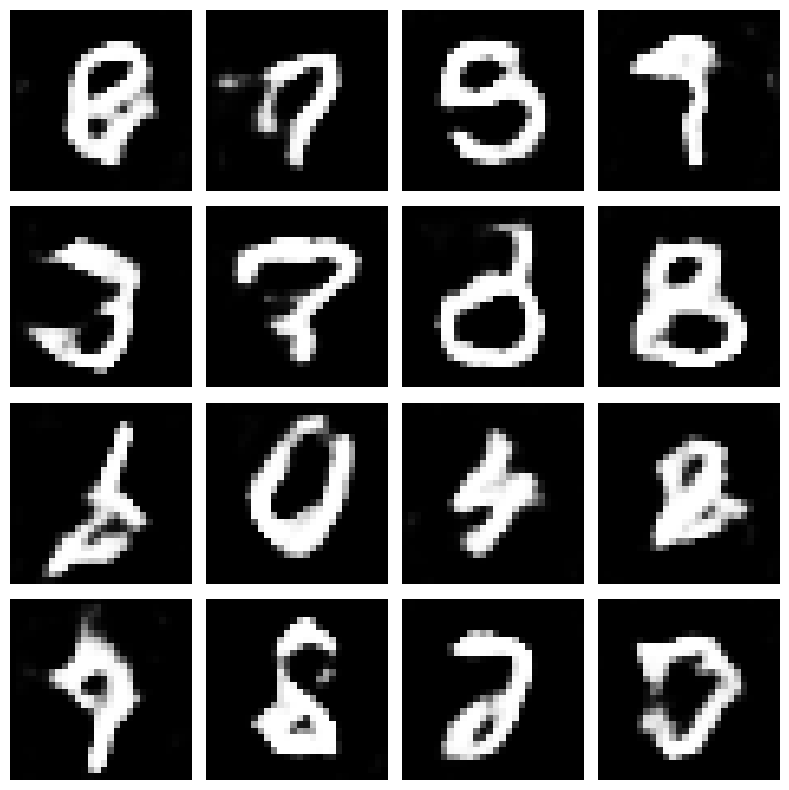

Epoch 009 | Step 0100 | G Loss: 0.9212 | D Loss: 1.3351
Epoch 009 | Step 0200 | G Loss: 0.8727 | D Loss: 1.2913
Epoch 009/040 completed in 11.1s | Mean G Loss: 0.8699 | Mean D Loss: 1.3247


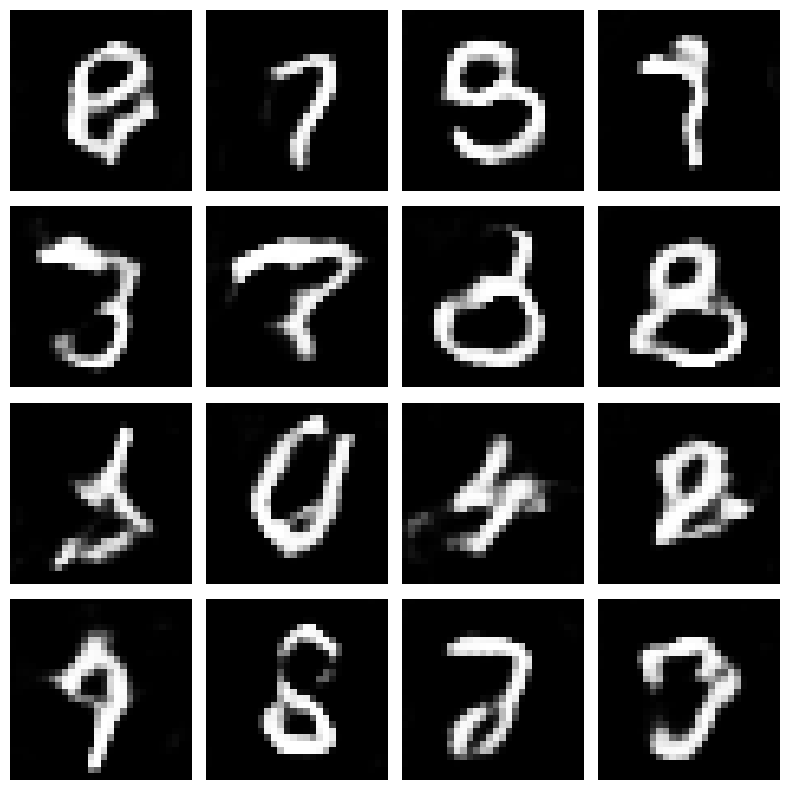

Epoch 010 | Step 0100 | G Loss: 0.8351 | D Loss: 1.2897
Epoch 010 | Step 0200 | G Loss: 0.8452 | D Loss: 1.3257
Epoch 010/040 completed in 11.2s | Mean G Loss: 0.8532 | Mean D Loss: 1.3252


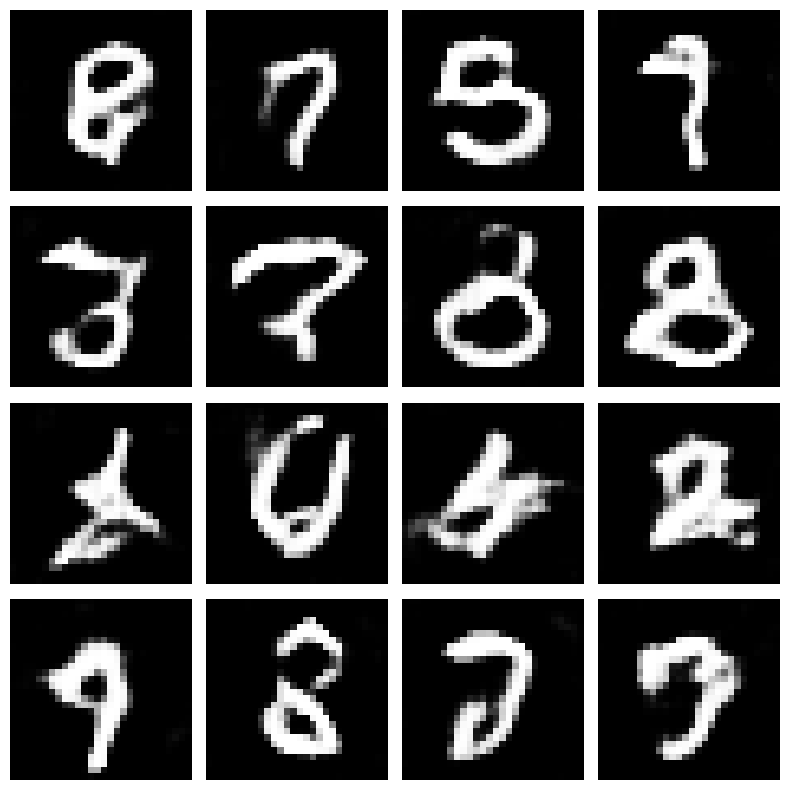

Checkpoint saved: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\checkpoints_dcgan_torch\dcgan_epoch_010.pt
Epoch 011 | Step 0100 | G Loss: 0.8438 | D Loss: 1.3386
Epoch 011 | Step 0200 | G Loss: 0.8920 | D Loss: 1.3677
Epoch 011/040 completed in 11.5s | Mean G Loss: 0.8427 | Mean D Loss: 1.3286


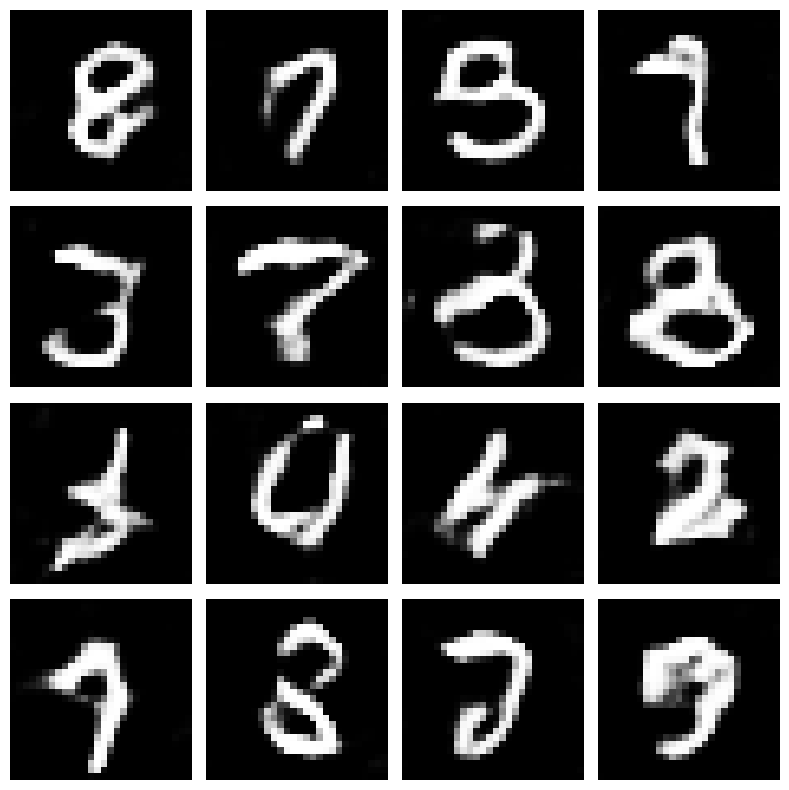

Epoch 012 | Step 0100 | G Loss: 0.8847 | D Loss: 1.3369
Epoch 012 | Step 0200 | G Loss: 0.8975 | D Loss: 1.3187
Epoch 012/040 completed in 11.6s | Mean G Loss: 0.8449 | Mean D Loss: 1.3395


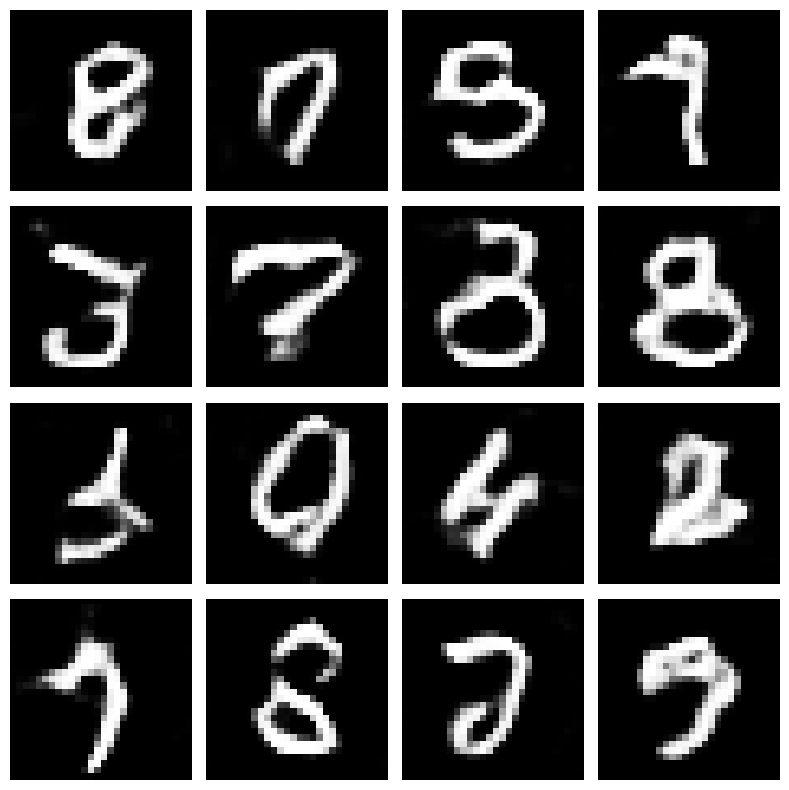

Epoch 013 | Step 0100 | G Loss: 0.8467 | D Loss: 1.3160
Epoch 013 | Step 0200 | G Loss: 0.8068 | D Loss: 1.3218
Epoch 013/040 completed in 11.1s | Mean G Loss: 0.8317 | Mean D Loss: 1.3366


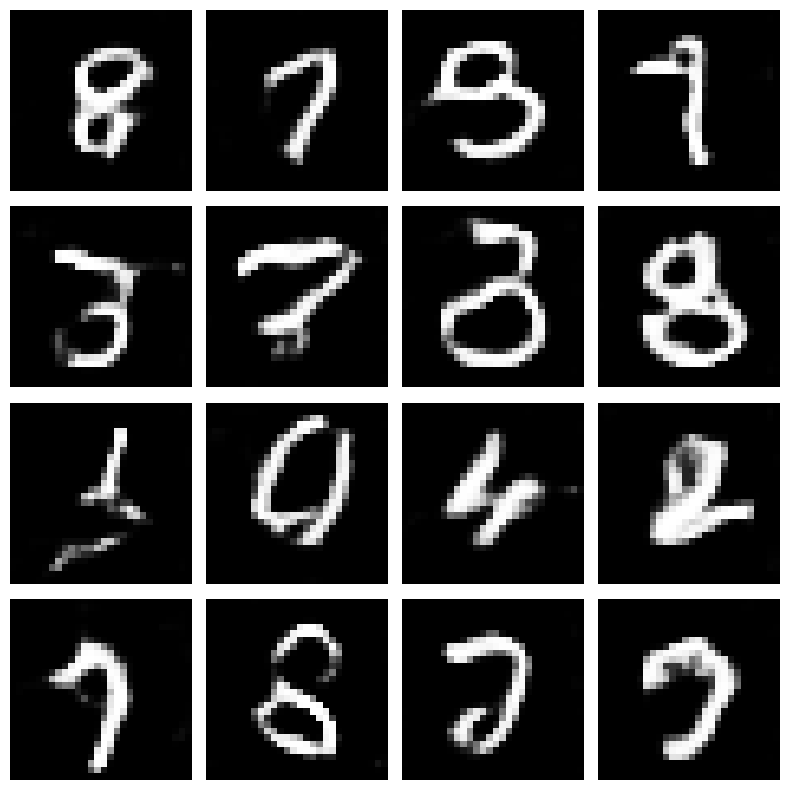

Epoch 014 | Step 0100 | G Loss: 0.8415 | D Loss: 1.3657
Epoch 014 | Step 0200 | G Loss: 0.8328 | D Loss: 1.3396
Epoch 014/040 completed in 11.1s | Mean G Loss: 0.8271 | Mean D Loss: 1.3425


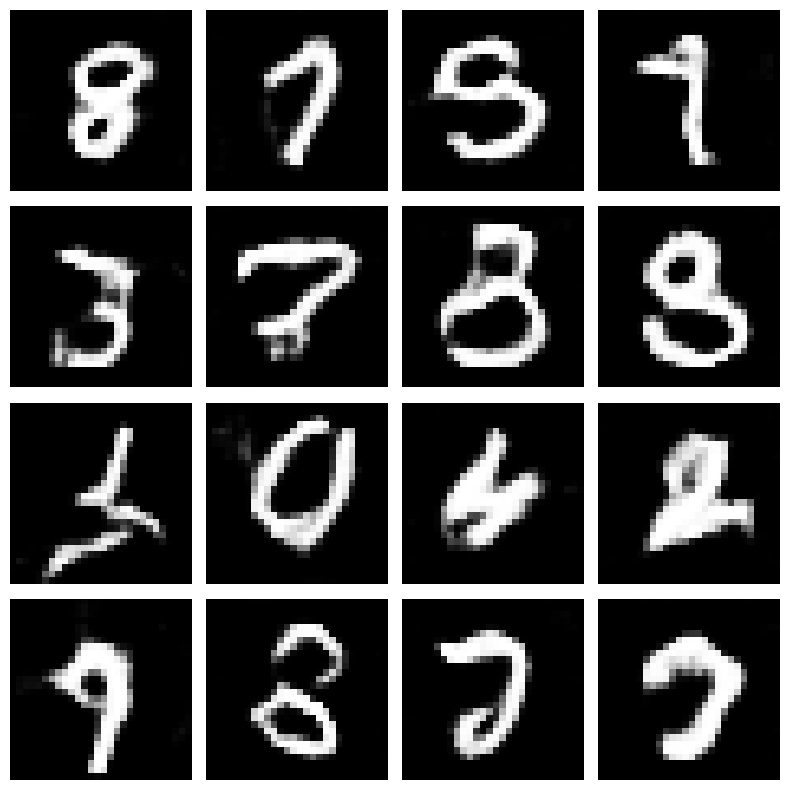

Epoch 015 | Step 0100 | G Loss: 0.8535 | D Loss: 1.3539
Epoch 015 | Step 0200 | G Loss: 0.7771 | D Loss: 1.3635
Epoch 015/040 completed in 11.4s | Mean G Loss: 0.8178 | Mean D Loss: 1.3399


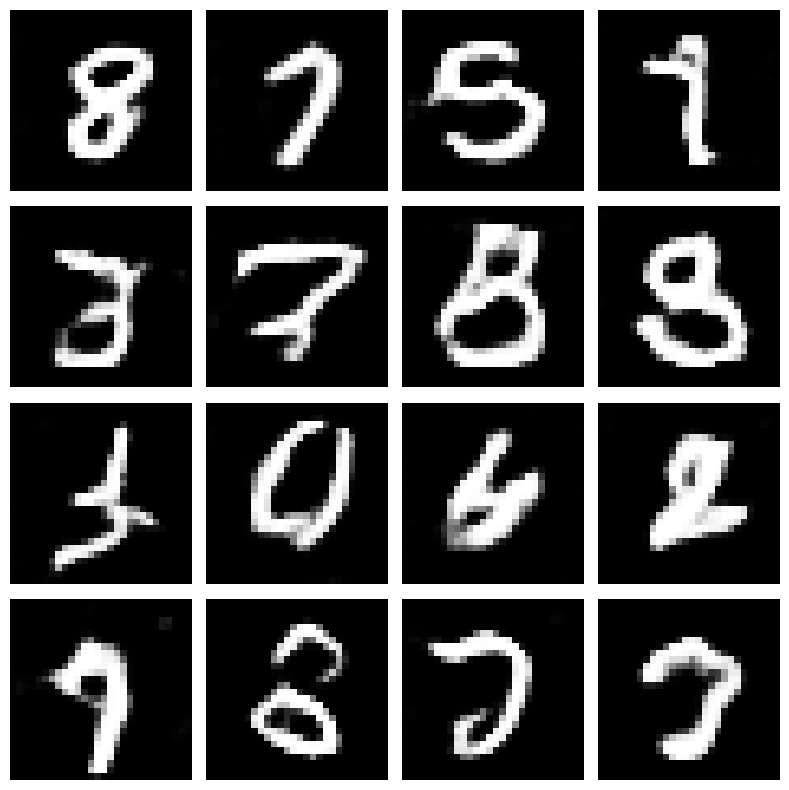

Checkpoint saved: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\checkpoints_dcgan_torch\dcgan_epoch_015.pt
Epoch 016 | Step 0100 | G Loss: 0.8886 | D Loss: 1.3359
Epoch 016 | Step 0200 | G Loss: 0.6352 | D Loss: 1.4046
Epoch 016/040 completed in 11.2s | Mean G Loss: 0.8149 | Mean D Loss: 1.3459


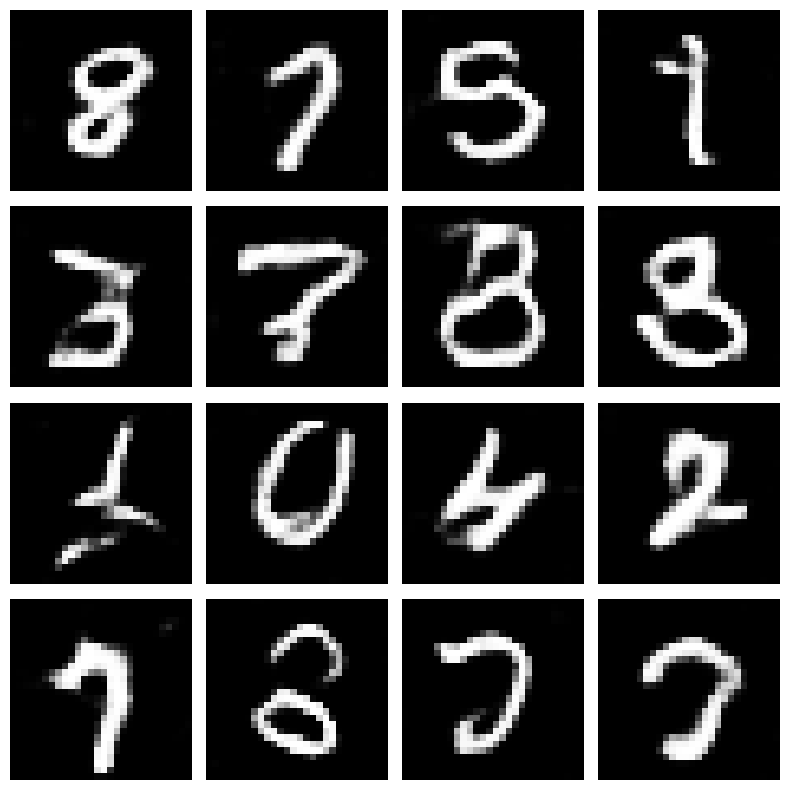

Epoch 017 | Step 0100 | G Loss: 0.9256 | D Loss: 1.2950
Epoch 017 | Step 0200 | G Loss: 0.9102 | D Loss: 1.3366
Epoch 017/040 completed in 11.3s | Mean G Loss: 0.8100 | Mean D Loss: 1.3477


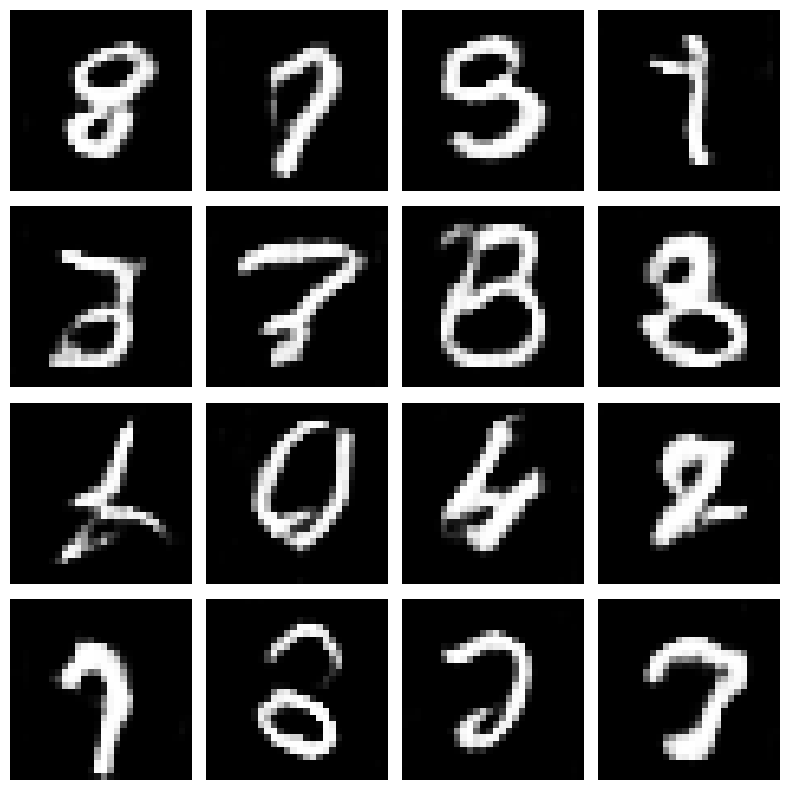

Epoch 018 | Step 0100 | G Loss: 0.8972 | D Loss: 1.3307
Epoch 018 | Step 0200 | G Loss: 0.8404 | D Loss: 1.3513
Epoch 018/040 completed in 11.1s | Mean G Loss: 0.8143 | Mean D Loss: 1.3493


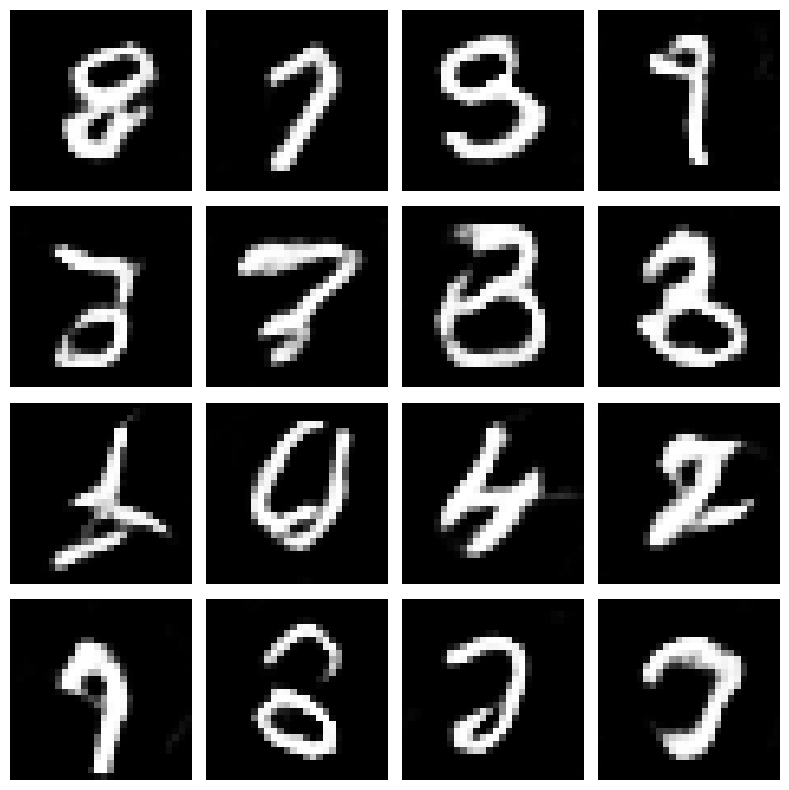

Epoch 019 | Step 0100 | G Loss: 0.6854 | D Loss: 1.3620
Epoch 019 | Step 0200 | G Loss: 0.9177 | D Loss: 1.3448
Epoch 019/040 completed in 11.2s | Mean G Loss: 0.7986 | Mean D Loss: 1.3470


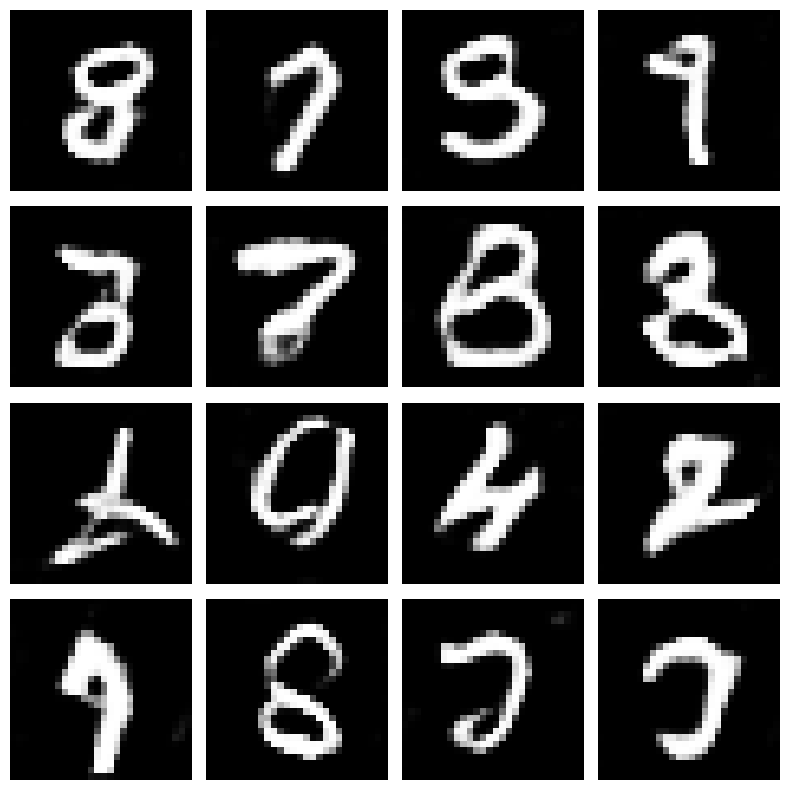

Epoch 020 | Step 0100 | G Loss: 0.8221 | D Loss: 1.3423
Epoch 020 | Step 0200 | G Loss: 0.8213 | D Loss: 1.3742
Epoch 020/040 completed in 11.1s | Mean G Loss: 0.7975 | Mean D Loss: 1.3491


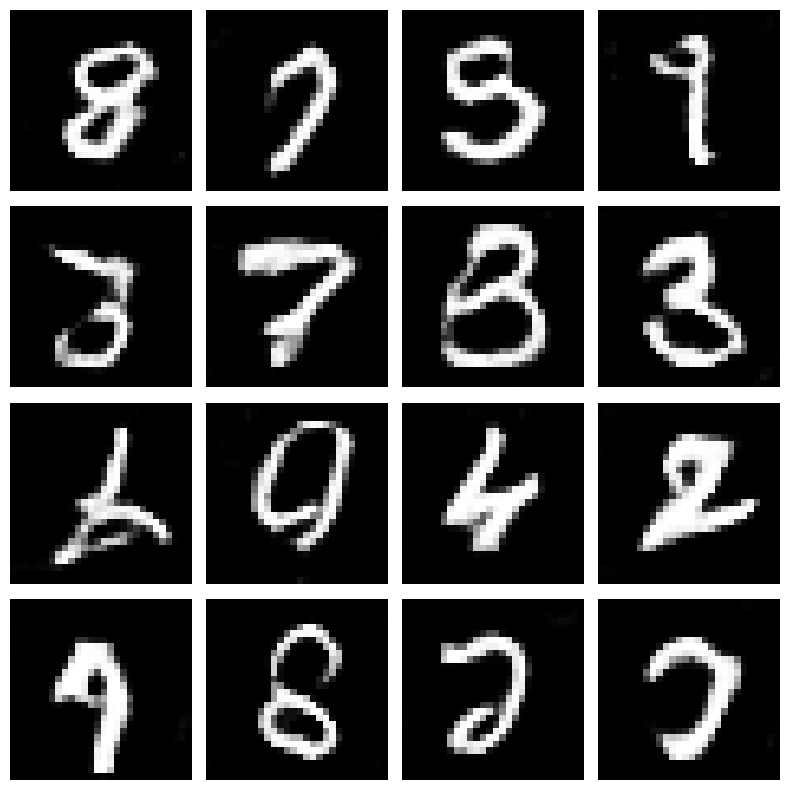

Checkpoint saved: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\checkpoints_dcgan_torch\dcgan_epoch_020.pt
Epoch 021 | Step 0100 | G Loss: 0.8686 | D Loss: 1.3684
Epoch 021 | Step 0200 | G Loss: 0.7402 | D Loss: 1.3976
Epoch 021/040 completed in 11.3s | Mean G Loss: 0.7997 | Mean D Loss: 1.3549


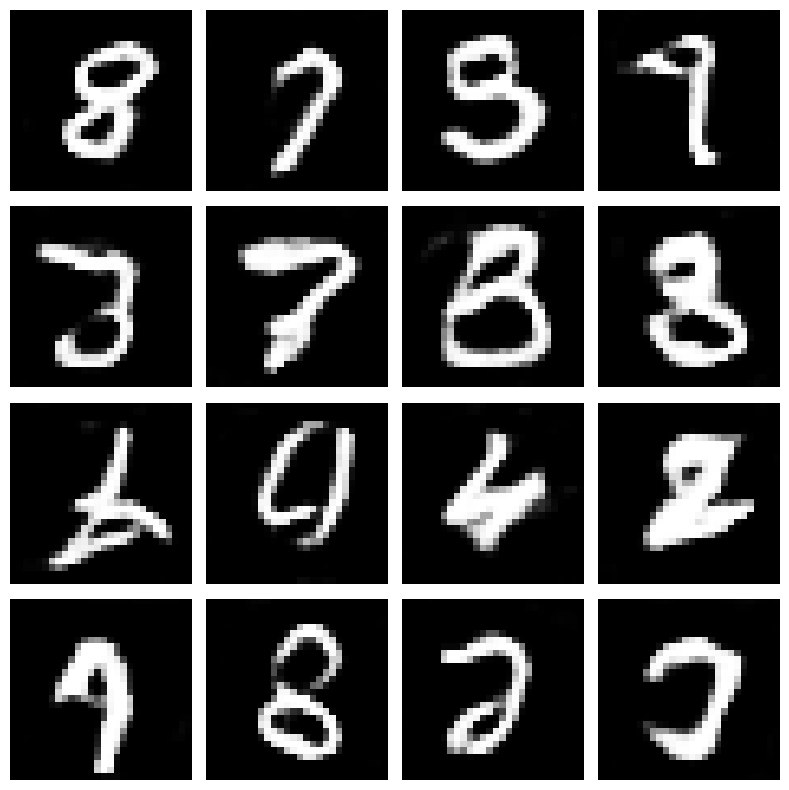

Epoch 022 | Step 0100 | G Loss: 0.7965 | D Loss: 1.3597
Epoch 022 | Step 0200 | G Loss: 0.7991 | D Loss: 1.3177
Epoch 022/040 completed in 11.3s | Mean G Loss: 0.7914 | Mean D Loss: 1.3555


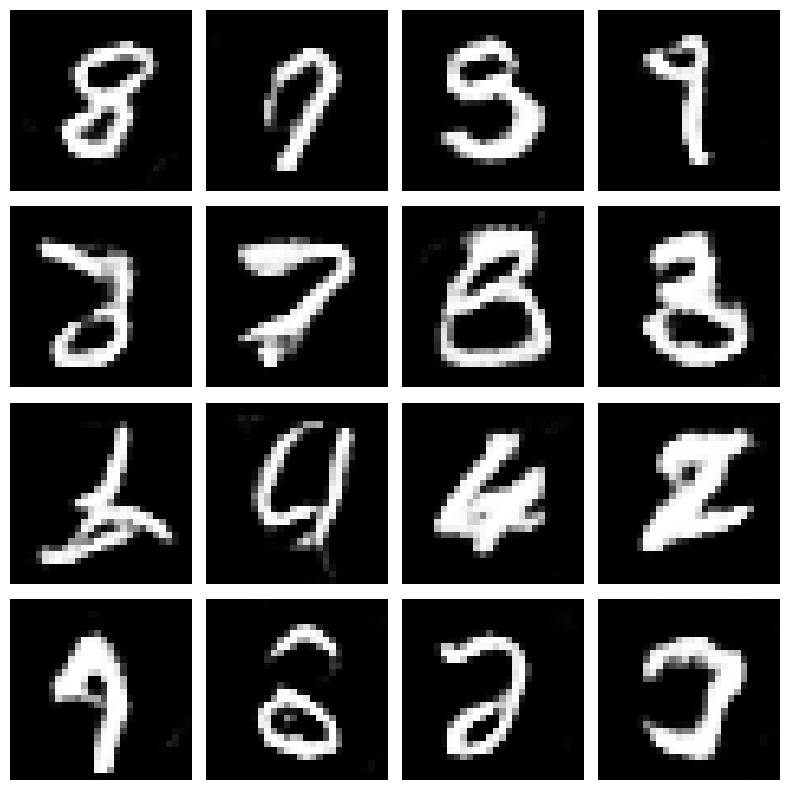

Epoch 023 | Step 0100 | G Loss: 0.8311 | D Loss: 1.3218
Epoch 023 | Step 0200 | G Loss: 0.7520 | D Loss: 1.3401
Epoch 023/040 completed in 11.4s | Mean G Loss: 0.7996 | Mean D Loss: 1.3557


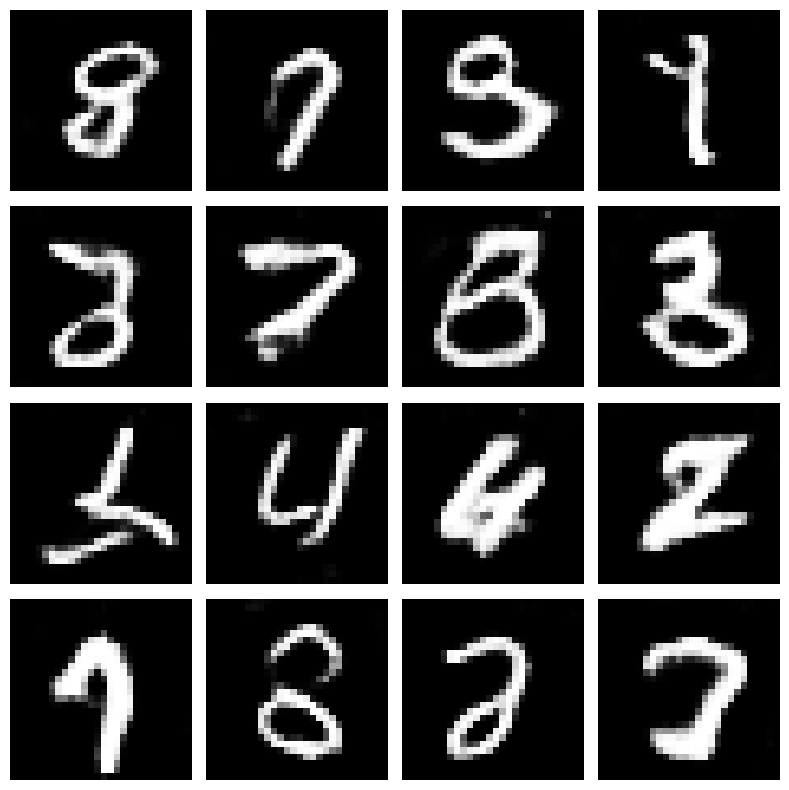

Epoch 024 | Step 0100 | G Loss: 0.8531 | D Loss: 1.3625
Epoch 024 | Step 0200 | G Loss: 0.7963 | D Loss: 1.3482
Epoch 024/040 completed in 11.3s | Mean G Loss: 0.7894 | Mean D Loss: 1.3544


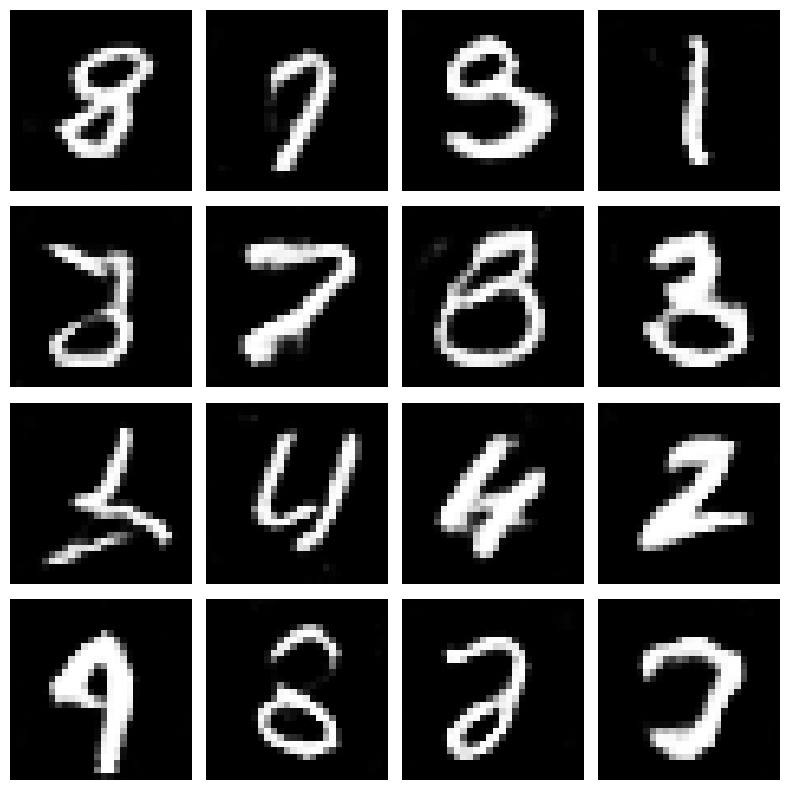

Epoch 025 | Step 0100 | G Loss: 0.7277 | D Loss: 1.3768
Epoch 025 | Step 0200 | G Loss: 0.8507 | D Loss: 1.3559
Epoch 025/040 completed in 11.2s | Mean G Loss: 0.7874 | Mean D Loss: 1.3535


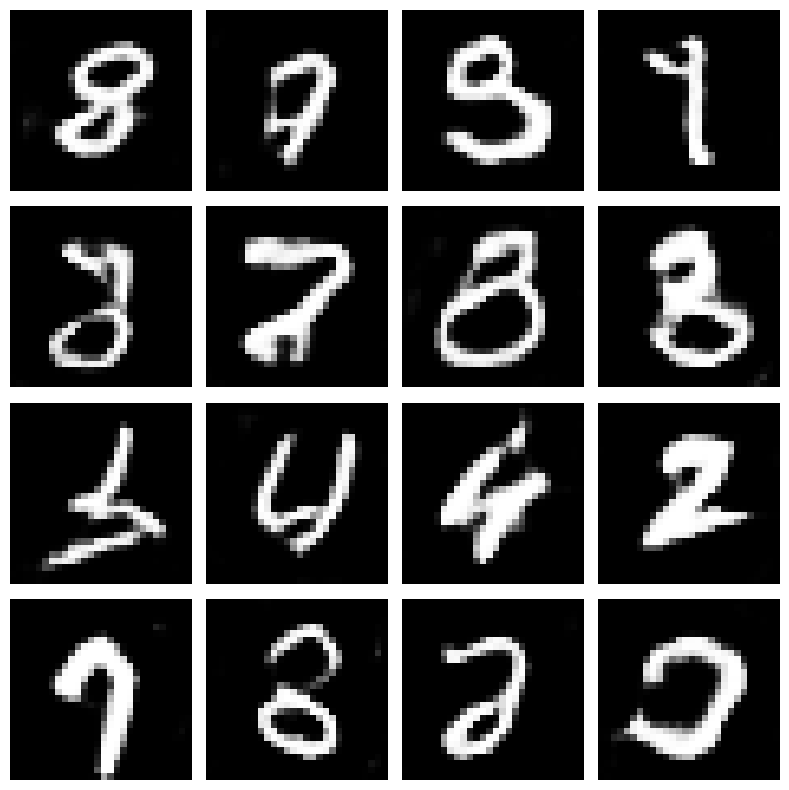

Checkpoint saved: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\checkpoints_dcgan_torch\dcgan_epoch_025.pt
Epoch 026 | Step 0100 | G Loss: 0.8645 | D Loss: 1.3819
Epoch 026 | Step 0200 | G Loss: 0.8299 | D Loss: 1.4502
Epoch 026/040 completed in 11.1s | Mean G Loss: 0.7921 | Mean D Loss: 1.3567


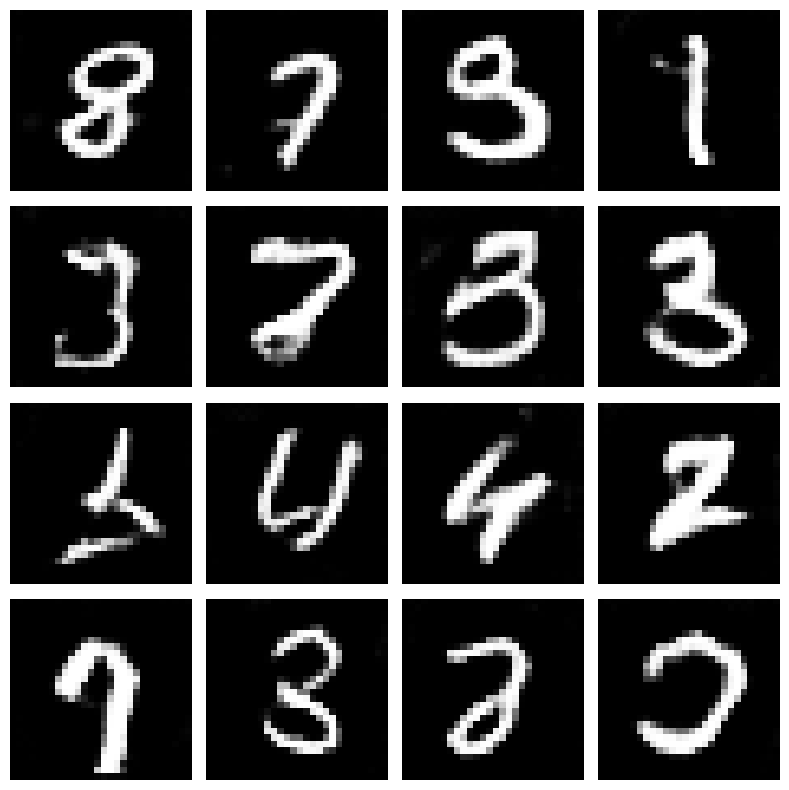

Epoch 027 | Step 0100 | G Loss: 0.8167 | D Loss: 1.3746
Epoch 027 | Step 0200 | G Loss: 0.9450 | D Loss: 1.3777
Epoch 027/040 completed in 11.1s | Mean G Loss: 0.7897 | Mean D Loss: 1.3592


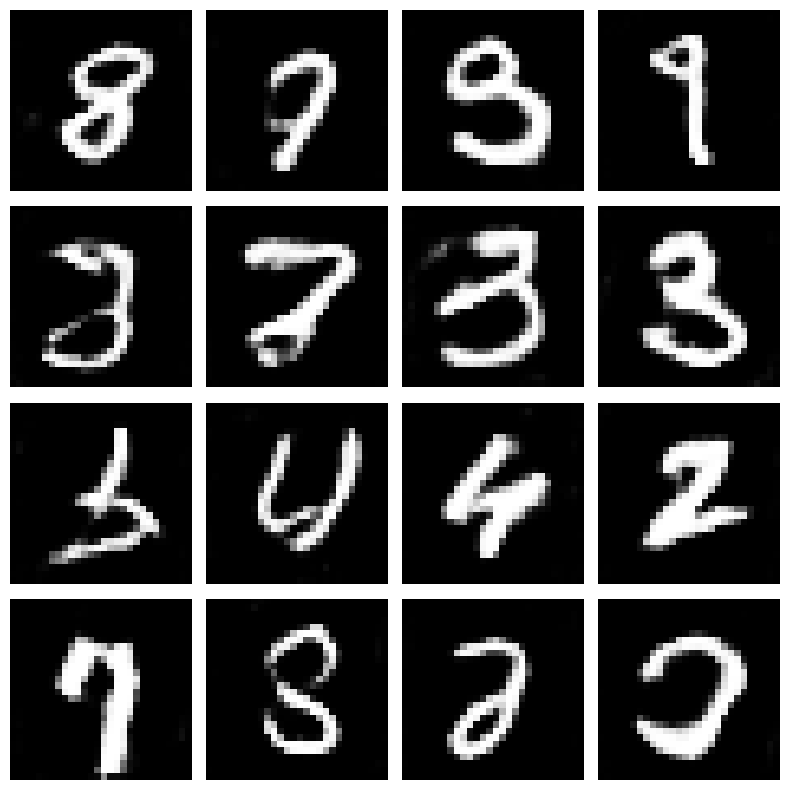

Epoch 028 | Step 0100 | G Loss: 0.7298 | D Loss: 1.3843
Epoch 028 | Step 0200 | G Loss: 0.7206 | D Loss: 1.3631
Epoch 028/040 completed in 11.3s | Mean G Loss: 0.7886 | Mean D Loss: 1.3579


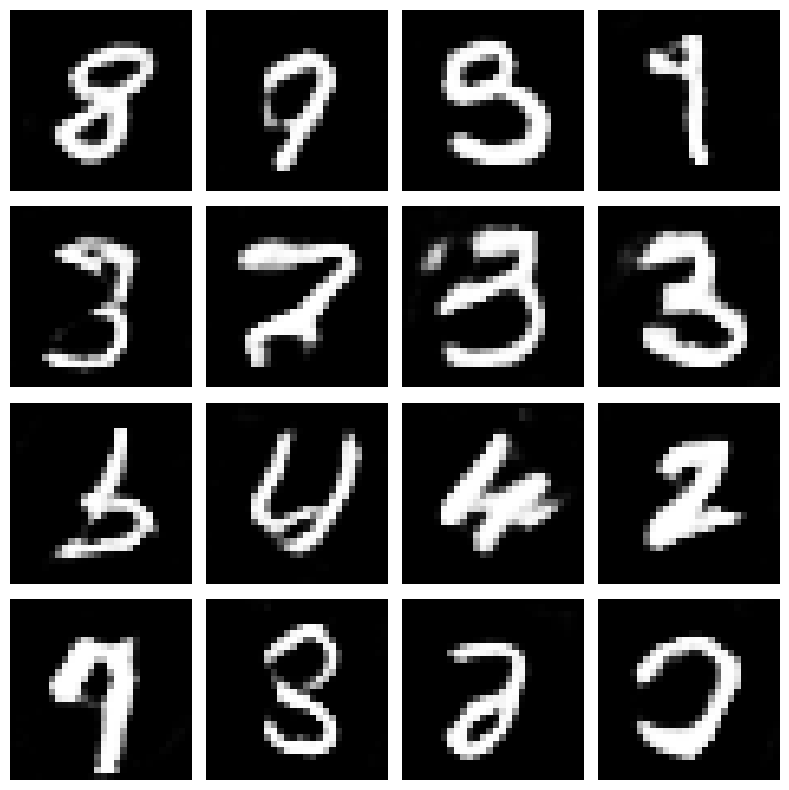

Epoch 029 | Step 0100 | G Loss: 0.7927 | D Loss: 1.3660
Epoch 029 | Step 0200 | G Loss: 0.8283 | D Loss: 1.3342
Epoch 029/040 completed in 11.3s | Mean G Loss: 0.7863 | Mean D Loss: 1.3587


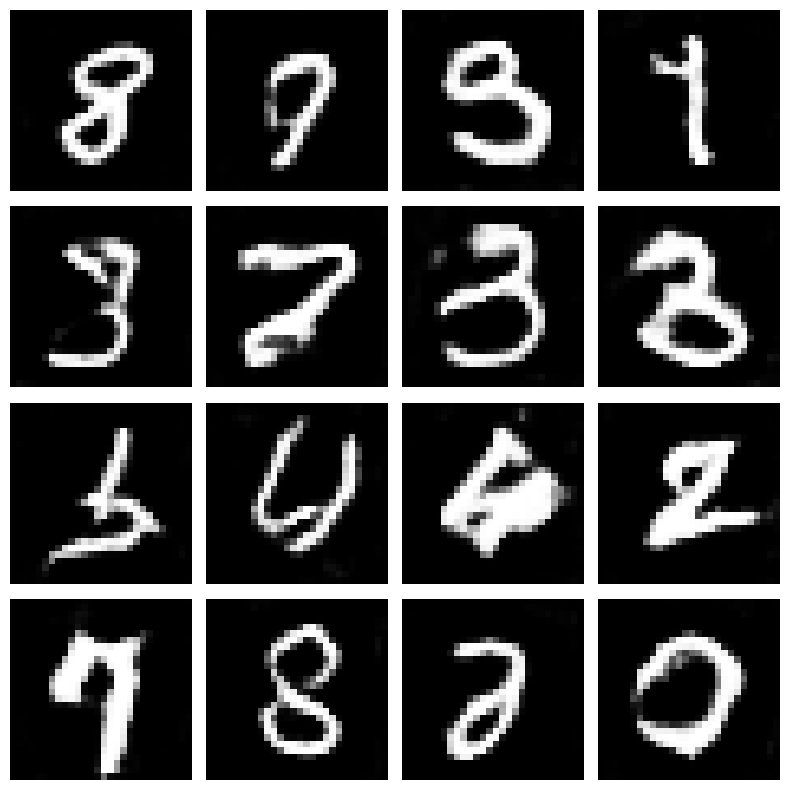

Epoch 030 | Step 0100 | G Loss: 0.7648 | D Loss: 1.3524
Epoch 030 | Step 0200 | G Loss: 0.8066 | D Loss: 1.3609
Epoch 030/040 completed in 11.2s | Mean G Loss: 0.7797 | Mean D Loss: 1.3589


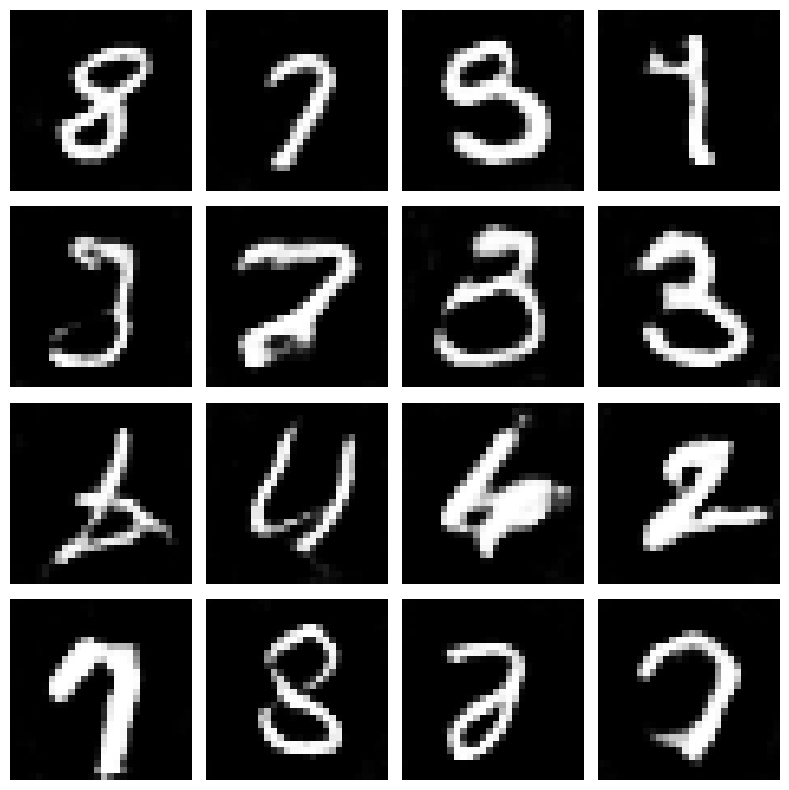

Checkpoint saved: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\checkpoints_dcgan_torch\dcgan_epoch_030.pt
Epoch 031 | Step 0100 | G Loss: 0.7440 | D Loss: 1.3053
Epoch 031 | Step 0200 | G Loss: 0.8099 | D Loss: 1.3558
Epoch 031/040 completed in 11.2s | Mean G Loss: 0.7774 | Mean D Loss: 1.3605


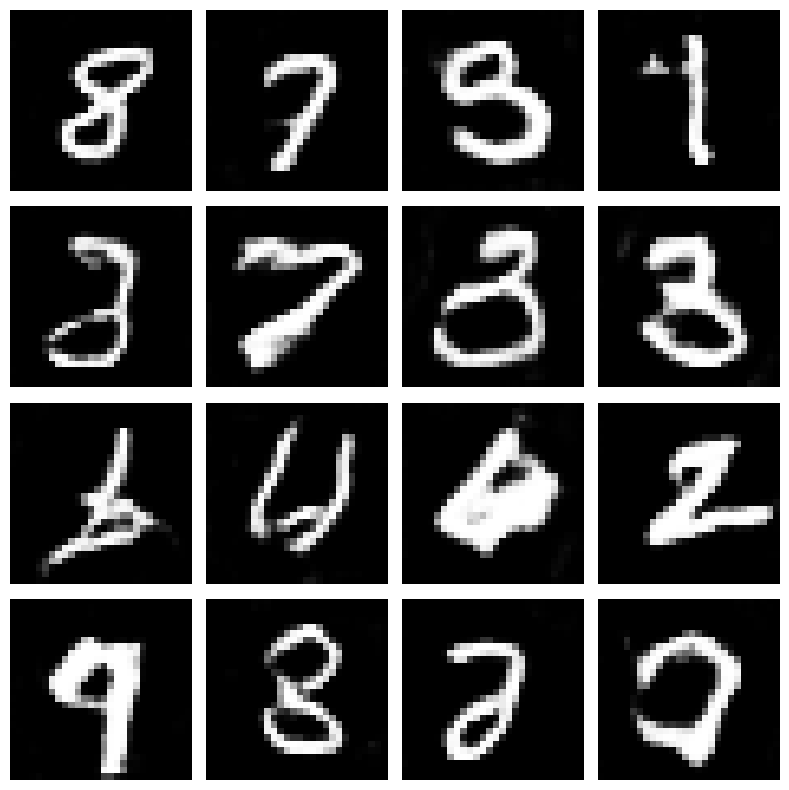

Epoch 032 | Step 0100 | G Loss: 0.7118 | D Loss: 1.3789
Epoch 032 | Step 0200 | G Loss: 0.7795 | D Loss: 1.3690
Epoch 032/040 completed in 11.3s | Mean G Loss: 0.7737 | Mean D Loss: 1.3601


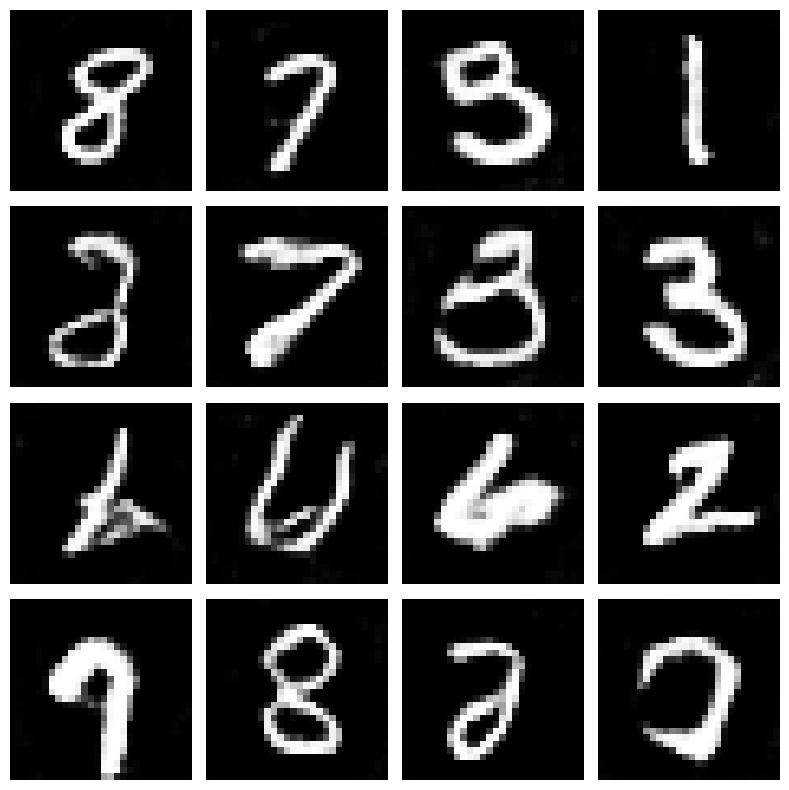

Epoch 033 | Step 0100 | G Loss: 0.7737 | D Loss: 1.3437
Epoch 033 | Step 0200 | G Loss: 0.7267 | D Loss: 1.3434
Epoch 033/040 completed in 11.2s | Mean G Loss: 0.7760 | Mean D Loss: 1.3584


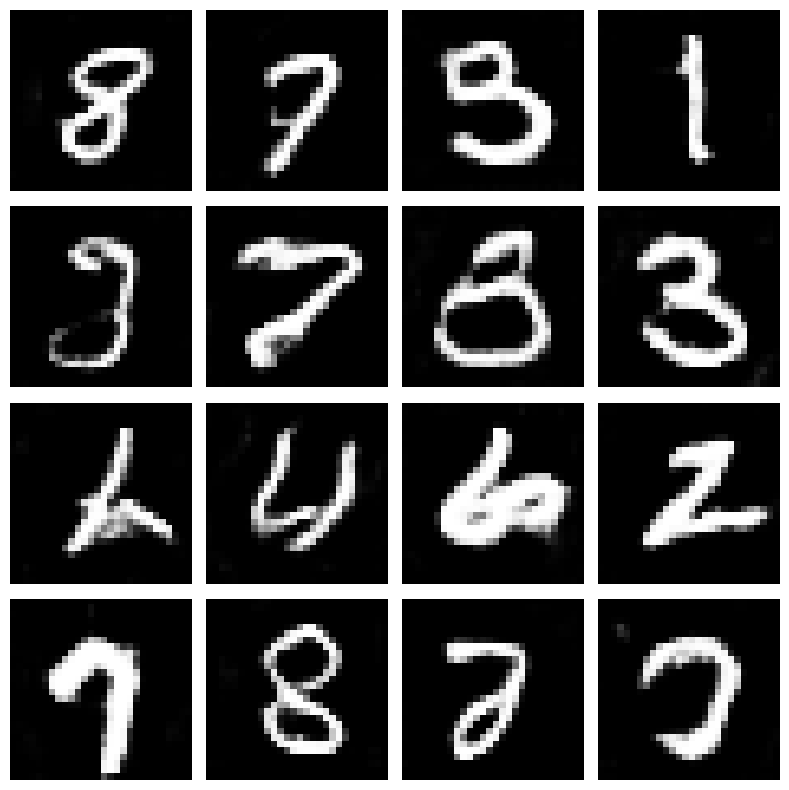

Epoch 034 | Step 0100 | G Loss: 0.7922 | D Loss: 1.3702
Epoch 034 | Step 0200 | G Loss: 0.7011 | D Loss: 1.3659
Epoch 034/040 completed in 11.2s | Mean G Loss: 0.7735 | Mean D Loss: 1.3648


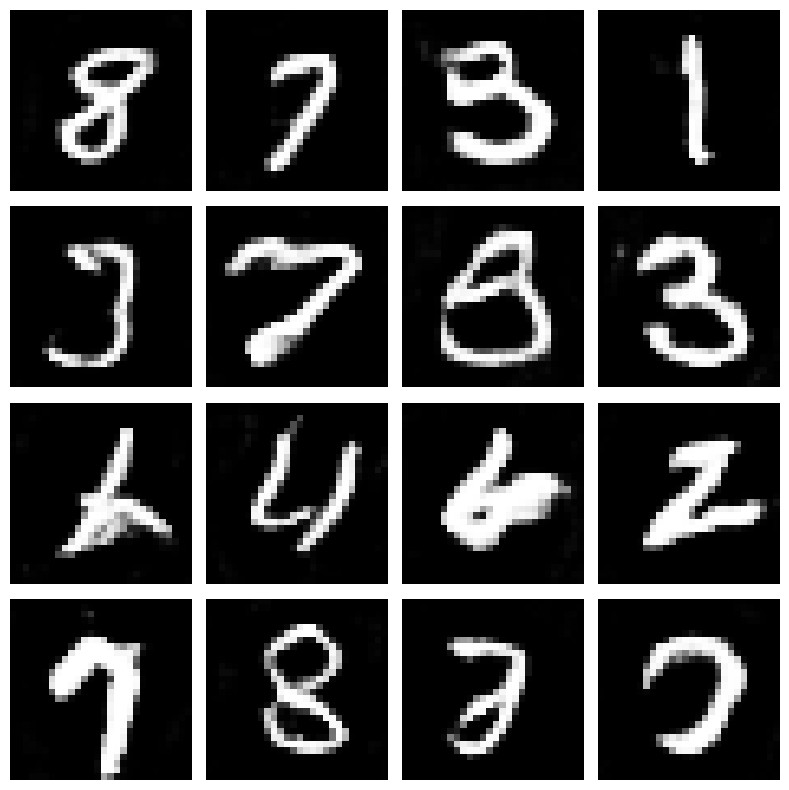

Epoch 035 | Step 0100 | G Loss: 0.6936 | D Loss: 1.4168
Epoch 035 | Step 0200 | G Loss: 0.7561 | D Loss: 1.4197
Epoch 035/040 completed in 11.5s | Mean G Loss: 0.7689 | Mean D Loss: 1.3588


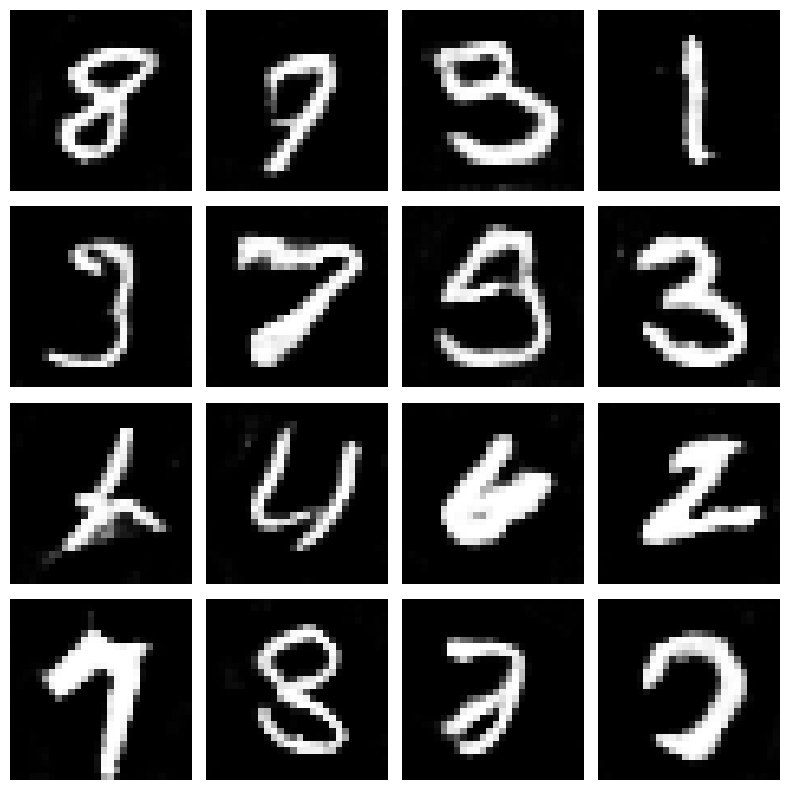

Checkpoint saved: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\checkpoints_dcgan_torch\dcgan_epoch_035.pt
Epoch 036 | Step 0100 | G Loss: 0.6876 | D Loss: 1.3623
Epoch 036 | Step 0200 | G Loss: 0.7650 | D Loss: 1.3582
Epoch 036/040 completed in 11.8s | Mean G Loss: 0.7686 | Mean D Loss: 1.3617


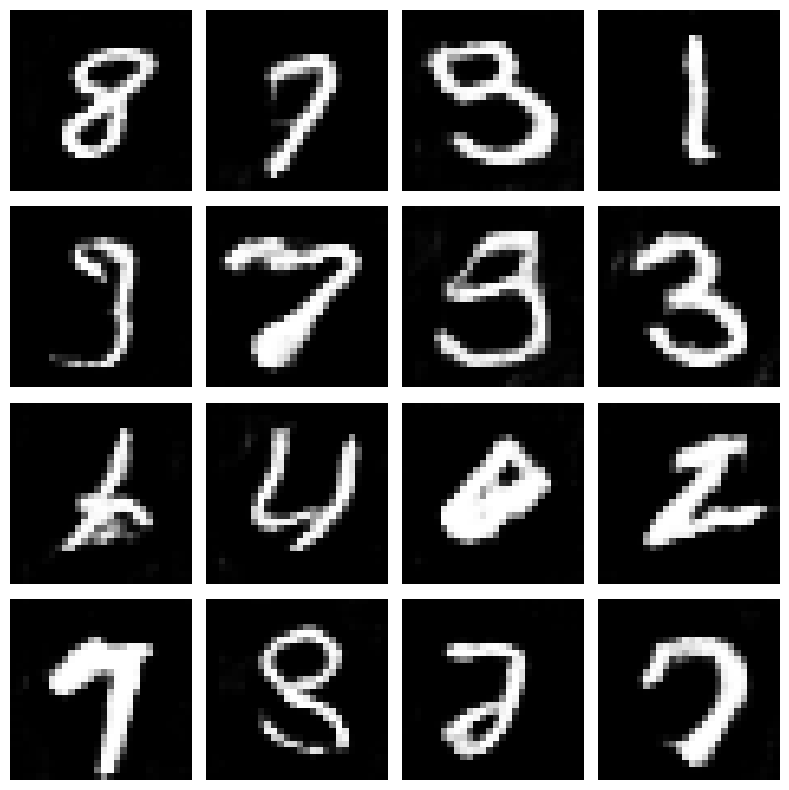

Epoch 037 | Step 0100 | G Loss: 0.7735 | D Loss: 1.3797
Epoch 037 | Step 0200 | G Loss: 0.7620 | D Loss: 1.3827
Epoch 037/040 completed in 11.2s | Mean G Loss: 0.7707 | Mean D Loss: 1.3660


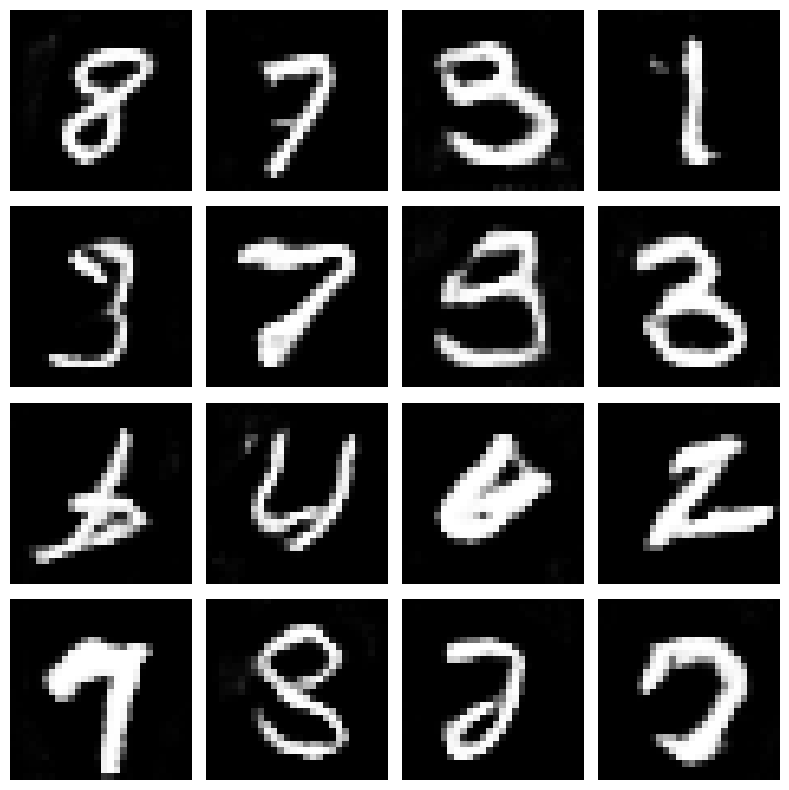

Epoch 038 | Step 0100 | G Loss: 0.8346 | D Loss: 1.3504
Epoch 038 | Step 0200 | G Loss: 0.7826 | D Loss: 1.4093
Epoch 038/040 completed in 11.1s | Mean G Loss: 0.7636 | Mean D Loss: 1.3611


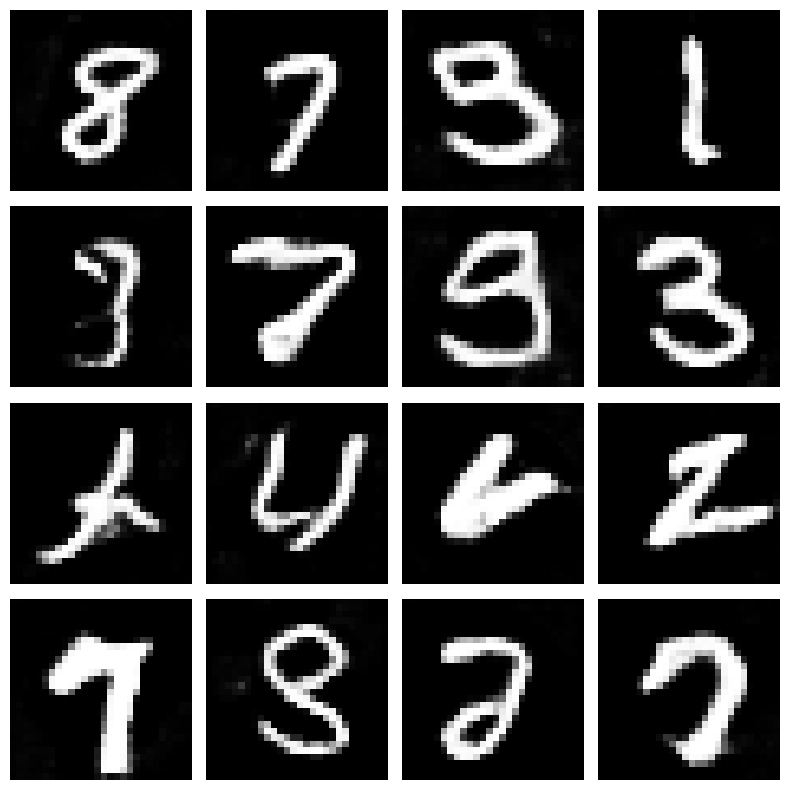

Epoch 039 | Step 0100 | G Loss: 0.6017 | D Loss: 1.3069
Epoch 039 | Step 0200 | G Loss: 0.7889 | D Loss: 1.3850
Epoch 039/040 completed in 11.6s | Mean G Loss: 0.7653 | Mean D Loss: 1.3664


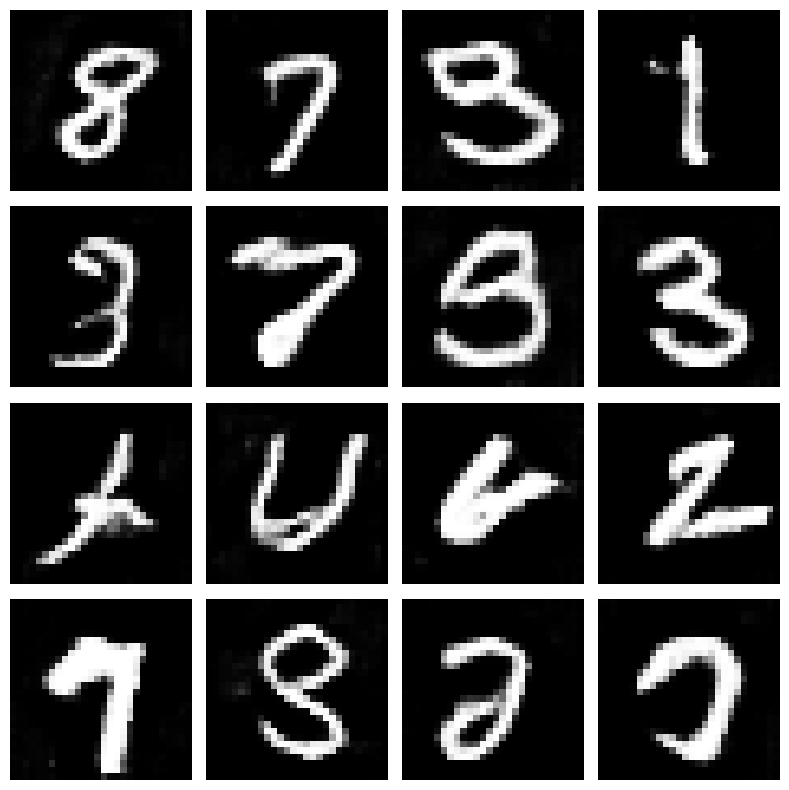

Epoch 040 | Step 0100 | G Loss: 0.8060 | D Loss: 1.3520
Epoch 040 | Step 0200 | G Loss: 0.8164 | D Loss: 1.4068
Epoch 040/040 completed in 11.9s | Mean G Loss: 0.7634 | Mean D Loss: 1.3659


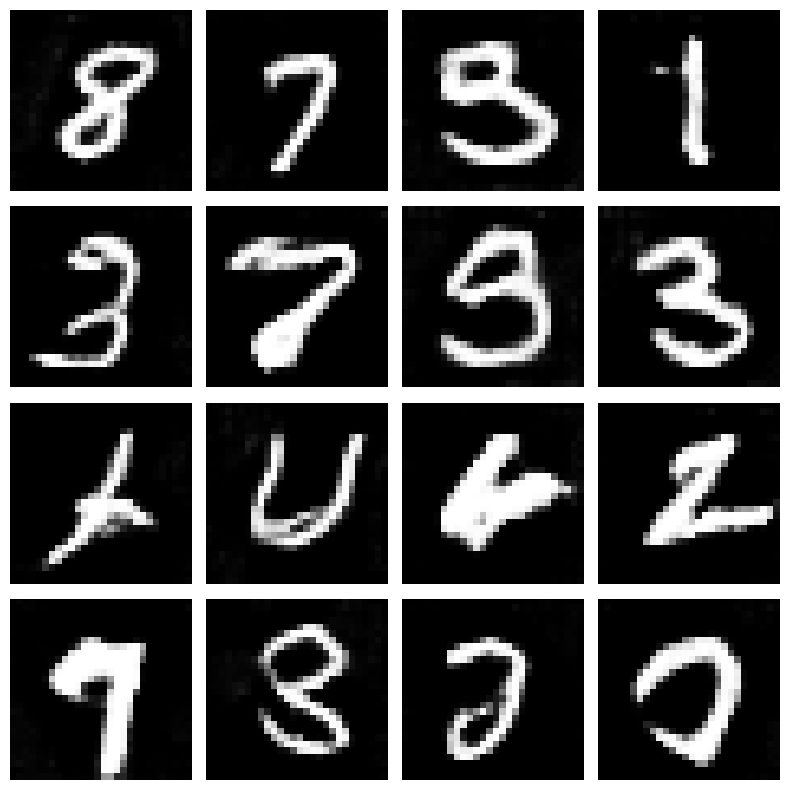

Checkpoint saved: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\checkpoints_dcgan_torch\dcgan_epoch_040.pt


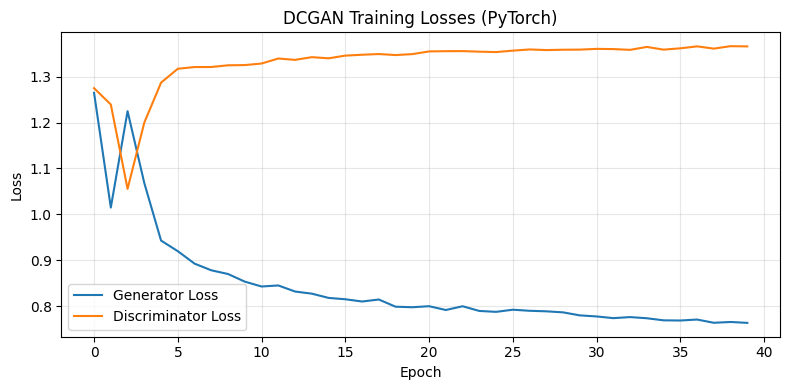

In [20]:
# Start DCGAN training
# You can lower EPOCHS (e.g., 20) for a faster run during experimentation.
generator.train()
discriminator.train()
g_history, d_history = train(train_loader, EPOCHS)

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(g_history, label="Generator Loss")
plt.plot(d_history, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Losses (PyTorch)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Generate and Display at Least 10 Synthetic Digits

This cell generates fresh samples from random latent vectors and displays **at least 10 digits** as the required assignment deliverable.

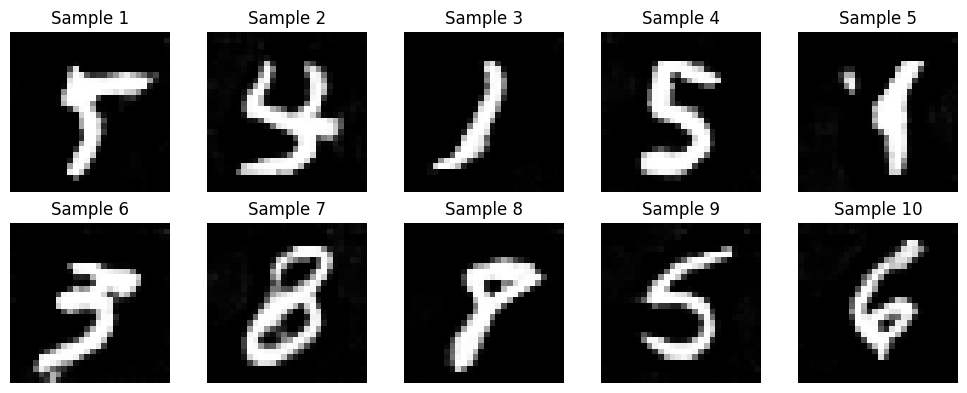

Saved final deliverable image to: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\generated_samples_torch\final_generated_10_digits.png


In [21]:
NUM_FINAL_SAMPLES = 10
z = torch.randn(NUM_FINAL_SAMPLES, NOISE_DIM, 1, 1, device=device)

generator.eval()
with torch.no_grad():
    gen_images = generator(z)

gen_images = ((gen_images + 1.0) / 2.0).clamp(0, 1).cpu()

grid_cols = 5
grid_rows = int(np.ceil(NUM_FINAL_SAMPLES / grid_cols))

plt.figure(figsize=(grid_cols * 2, grid_rows * 2))
for i in range(NUM_FINAL_SAMPLES):
    plt.subplot(grid_rows, grid_cols, i + 1)
    plt.imshow(gen_images[i, 0], cmap="gray")
    plt.title(f"Sample {i + 1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

final_grid_path = SAMPLES_DIR / "final_generated_10_digits.png"
plt.figure(figsize=(grid_cols * 2, grid_rows * 2))
for i in range(NUM_FINAL_SAMPLES):
    plt.subplot(grid_rows, grid_cols, i + 1)
    plt.imshow(gen_images[i, 0], cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.savefig(final_grid_path, dpi=140, bbox_inches="tight")
plt.close()

print("Saved final deliverable image to:", final_grid_path.resolve())

Saved generator to: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\saved_models_torch\generator_state_dict.pth
Saved discriminator to: E:\UNI STUFF\Semester 6\DlpSpring26\Assignment_03\saved_models_torch\discriminator_state_dict.pth


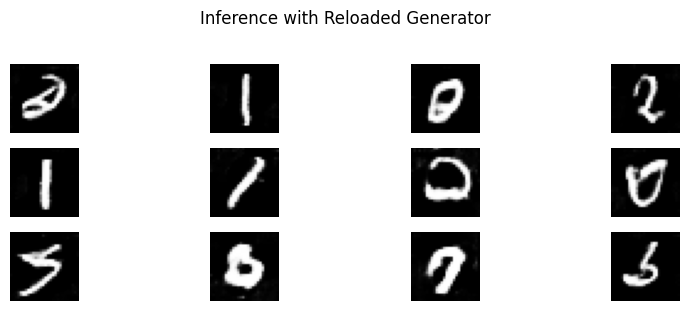

Reloaded inference completed successfully.


In [22]:
generator_path = MODELS_DIR / "generator_state_dict.pth"
discriminator_path = MODELS_DIR / "discriminator_state_dict.pth"

torch.save(generator.state_dict(), generator_path)
torch.save(discriminator.state_dict(), discriminator_path)

print("Saved generator to:", generator_path.resolve())
print("Saved discriminator to:", discriminator_path.resolve())

# Reload generator and test inference
reloaded_generator = Generator(NOISE_DIM).to(device)
reloaded_generator.load_state_dict(torch.load(generator_path, map_location=device))
reloaded_generator.eval()

z_test = torch.randn(12, NOISE_DIM, 1, 1, device=device)
with torch.no_grad():
    reload_images = reloaded_generator(z_test)
reload_images = ((reload_images + 1.0) / 2.0).clamp(0, 1).cpu()

plt.figure(figsize=(9, 3))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(reload_images[i, 0], cmap="gray")
    plt.axis("off")
plt.suptitle("Inference with Reloaded Generator", y=1.02)
plt.tight_layout()
plt.show()

print("Reloaded inference completed successfully.")